# Preprocess

In [ ]:
from pipeline_preprocess import run_full_pipeline
resultats = run_full_pipeline(r"C:\TSQ\data\data1.csv")

df = resultats["df"]
df_PS = resultats["df_PS"]
df_PD = resultats["df_PD"]

df_SD = resultats["df_SD"]
df_SD_PS = resultats["df_SD_PS"]
df_SD_PD = resultats["df_SD_PD"]

df_BAI = resultats["df_BAI"]
df_TSQ = resultats["df_TSQ"]
df_TSQ_PD = resultats["df_TSQ_PD"]

df_EP = resultats["df_EP"]
df_EP_PD = resultats["df_EP_PD"]

df_16 = resultats["df_16"]
df_16_PD = resultats["df_16_PD"]
echelle1 = resultats["echelle1"]
echelle2 = resultats["echelle2"]

df_sub = resultats["df_sub"]

df_ZTPI = resultats["df_ZTPI"]
df_ZTPI_PD = resultats["df_ZTPI_PD"]


Nombre de lignes complètement vides : 0


# Création de groupes au sein de l'échelle TSQ: 0 = sain,  1 = personne avec diag

In [ ]:
import pandas as pd
df_TSQ = df_TSQ.copy()
df_TSQ["group"] = 0

df_TSQ_PD = df_TSQ_PD.copy()
df_TSQ_PD["group"] = 1

df_all = pd.concat([df_TSQ, df_TSQ_PD])
group = df_all["group"]          
df_all = df_all.drop(columns="group")   


In [ ]:
dfs = [df_TSQ, df_TSQ_PD, df_all]

for df in dfs:
    
    cols_tsq_brutes = df.columns[0:40]

    # On renomme les 40 items : TSQ1 → TSQ40
    new_names = [f"TSQ{i}" for i in range(1, 41)]
    df.rename(columns=dict(zip(cols_tsq_brutes, new_names)), inplace=True)

    df[new_names] = df[new_names].apply(
        lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float)
    )


# Correlation des 40x40 items + greedy glouton

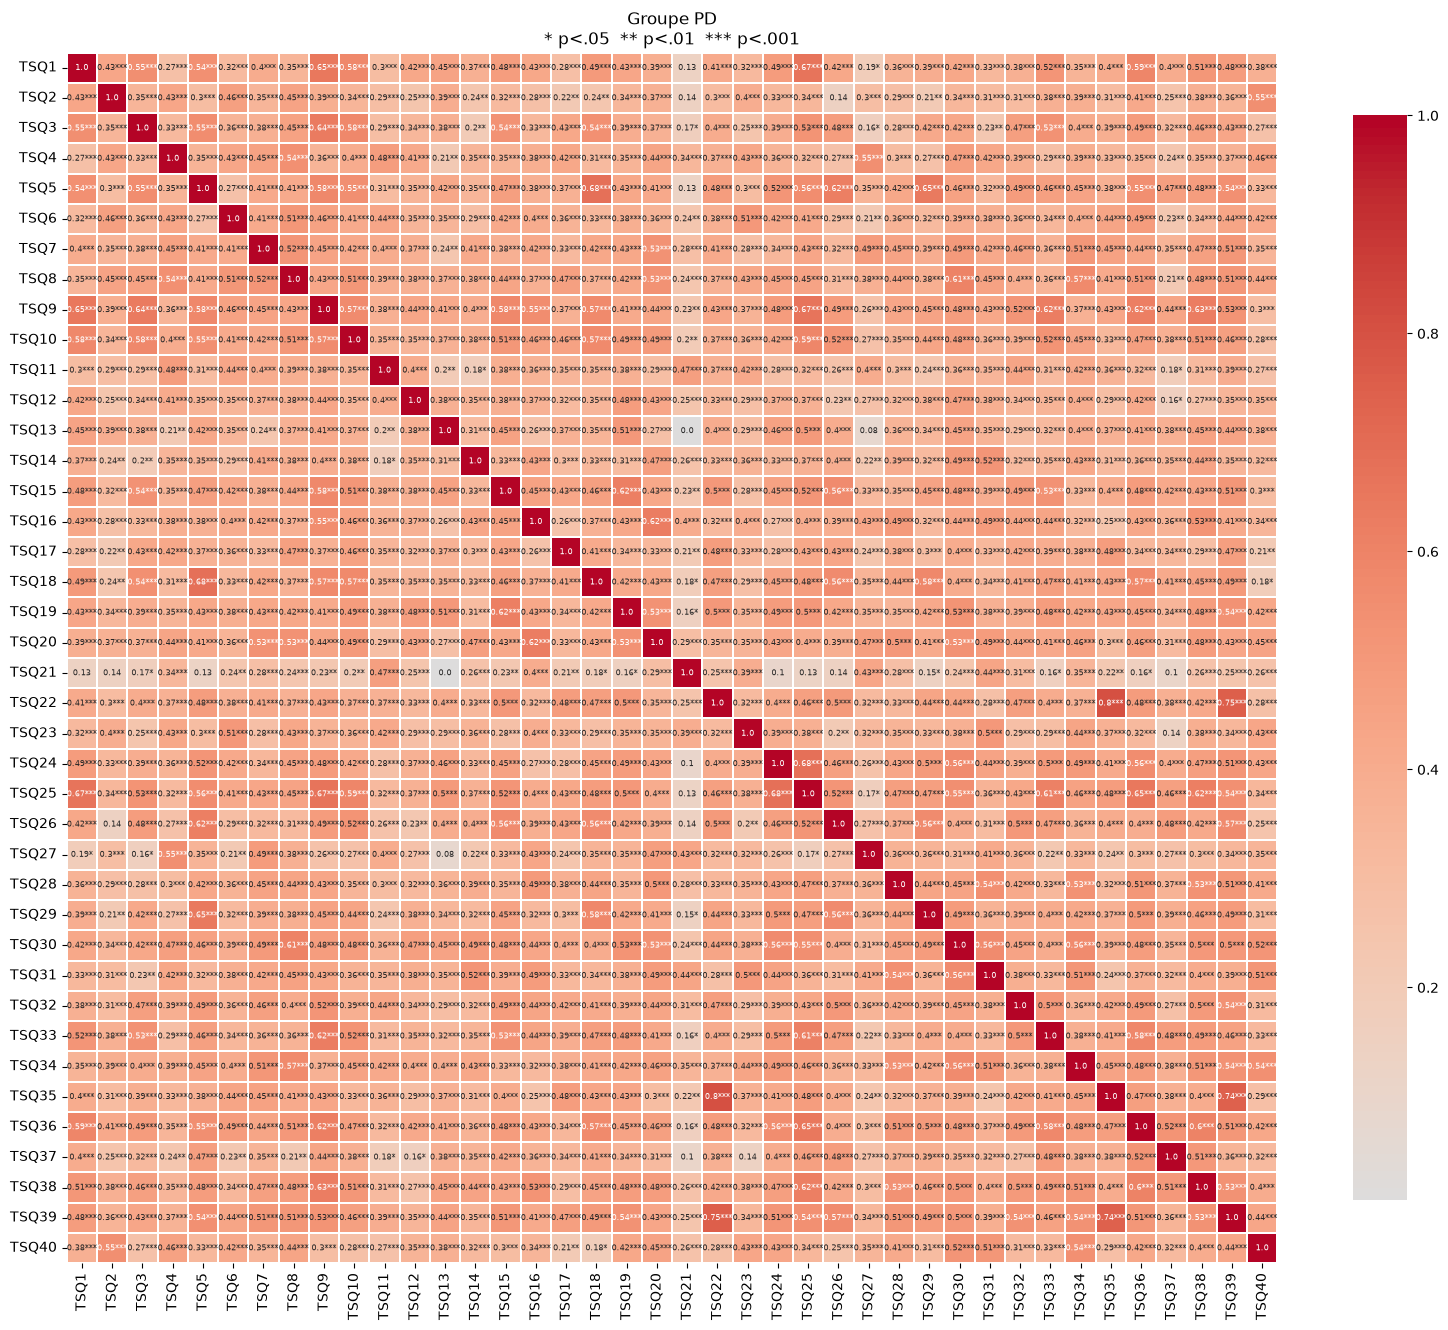

Items conservés : ['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']
Items retirés : ['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39']


In [ ]:
from correl_TSQ import compute_tsq_corr

compute_tsq_corr(df_all, items=[f"TSQ{i}" for i in range(1, 41)], title="Matrice de correlation 40x40 - tous les participants")

from correl_TSQ import reduce_correlated_features
items = [f"TSQ{i}" for i in range(1, 41)]
selected_items = reduce_correlated_features(df_all, items, threshold=0.65)

print("Items conservés :", selected_items)
print("Items retirés :", [i for i in items if i not in selected_items])



In [16]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39', 'score_total']  # remplace par tes colonnes
df_red_sains = df_TSQ.drop(columns=colonnes_a_exclure)
df_red_pd = df_TSQ_PD.drop(columns=colonnes_a_exclure)

# Split train/test des participants sains + UMAP sur train + Clustering sur train + Classifier (4 modeles) avec GridSearch 

c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    68
1    47
Name: count, dtype: int64
Cluster 0: 68 participants (group 0: 68)
Cluster 1: 47 participants (group 0: 47)

=== Répartition train (fit) ===
0    68
1    47
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    30
1     9
Name: count, dtype: int64

=== LogisticRegression ===
Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.956
Score sur test set : 0.944


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403

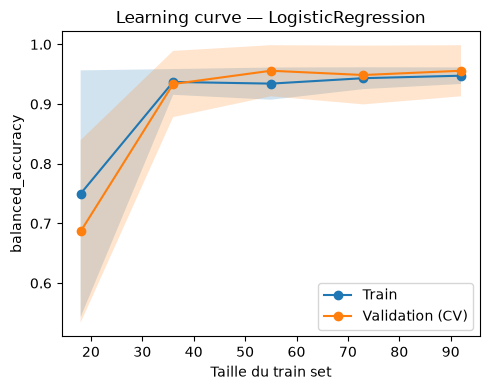


=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(

Meilleurs params : {'clf__C': 0.1, 'clf__gamma': 'scale'}
Meilleur score CV : 0.959
Score sur test set : 0.944


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


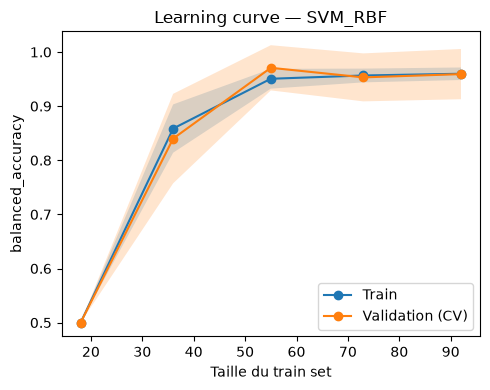


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.94
Score sur test set : 0.889


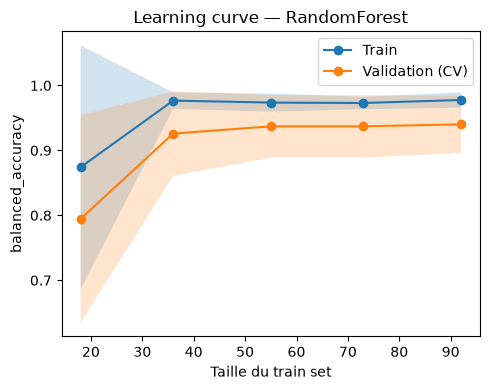


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.951
Score sur test set : 0.889


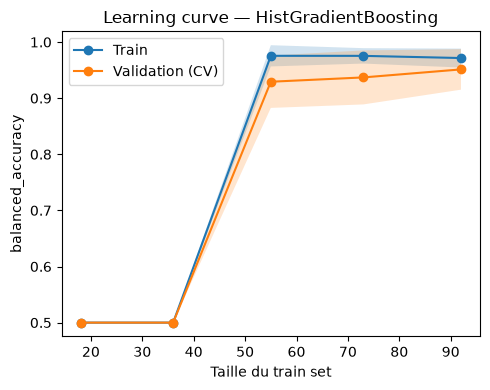


=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.959219    0.944444
LogisticRegression    0.955800    0.944444
HistGradientBoosting  0.951282    0.888889
RandomForest          0.940171    0.888889

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.89      0.94         9

    accuracy                           0.97        39
   macro avg       0.98      0.94      0.96        39
weighted avg       0.98      0.97      0.97        39



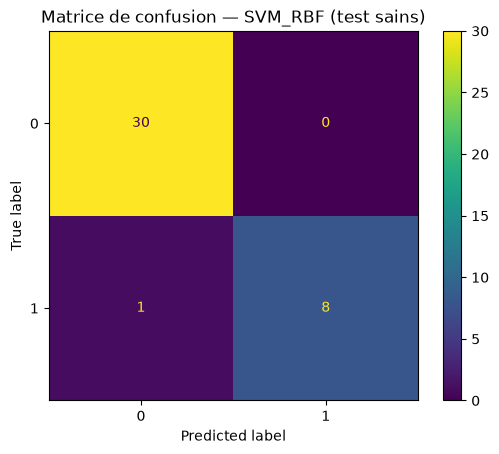

In [20]:
from testclust import split_umap_clustering_train_test
from pipeline_ML import train_and_compare_classifiers, apply_to_patients

split_result = split_umap_clustering_train_test(
    df_red_sains, n_clusters=2, test_size=0.25, random_state=42, group=group,
)

X_train, X_test = split_result["X_train_2d"], split_result["X_test_2d"]
y_train, y_test = split_result["y_train"], split_result["y_test"]

results, summary, best_model_name, best_model = train_and_compare_classifiers(
    X_train, y_train, X_test, y_test, scoring="balanced_accuracy"
)

# Réprésentation de la prédiction de la position des patients sur les clusterss 0 ou 1 dans l'espace UMAP des participants sains

In [ ]:
df_patients_pred = apply_to_patients(
    best_model,
    split_result["res_train"].umap_2d_model,   
    df_red_pd,
)

print(df_patients_pred["predicted_cluster"].value_counts().sort_index())

predicted_cluster
0    15
1    16
Name: count, dtype: int64


In [ ]:
import pandas as pd
import plotly.express as px

ps_train = split_result["ps_train"]

X_patients_umap = ps_train.umap_2d_model.transform(df_red_pd.values)

hover_train = [f"Participant {i}" for i in split_result["df_train"].index]
hover_test  = [f"Participant {i}" for i in split_result["df_test"].index]
hover_diag  = [f"Participant {i}" for i in df_red_pd.index]

df_plot = pd.concat([
    pd.DataFrame({
        "x": split_result["X_train_2d"][:, 0], "y": split_result["X_train_2d"][:, 1],
        "cluster": split_result["y_train"].astype(str),
        "type": "Sains (train)",
        "participant": hover_train,
    }),
    pd.DataFrame({
        "x": split_result["X_test_2d"][:, 0], "y": split_result["X_test_2d"][:, 1],
        "cluster": split_result["y_test"].astype(str),
        "type": "Sains (test)",
        "participant": hover_test,
    }),
    pd.DataFrame({
        "x": X_patients_umap[:, 0], "y": X_patients_umap[:, 1],
        "cluster": df_patients_pred["predicted_cluster"].astype(str),
        "type": "Diag",
        "participant": hover_diag,
    }),
], ignore_index=True)

fig = px.scatter(
    df_plot, x="x", y="y",
    color="cluster", symbol="type",
    color_discrete_map={"0": "#A777F1", "1":'#FC6955'},
    symbol_map={"Sains (train)": "circle", "Sains (test)": "circle-open", "Diag": "triangle-up"},
    opacity=0.7,
    hover_name="participant",
    title="Sains (train/test) et patients projetés dans l'espace UMAP (fit sur train)",
)

for trace in fig.data:
    if "Diag" in trace.name:
        trace.marker.line = dict(width=1, color="black")

fig.show(renderer="browser")

# Suite 
 * Split train/test des participants sains + UMAP sur train + Clustering sur train 
* creation de chaque df pour chaque groupes d'items
* ajouter à la boucle : Classifier (4 modeles) avec GridSearch pour chaque df
* visualisation du best model sur le groupe de participants diag

In [28]:
#Core items

items_core_sz = ['TSQ2','TSQ4','TSQ7','TSQ8','TSQ10','TSQ11','TSQ12','TSQ15','TSQ19','TSQ20','TSQ21','TSQ24','TSQ30','TSQ31','TSQ34','TSQ40']
items_core_md = ['TSQ9','TSQ14','TSQ17','TSQ25','TSQ28','TSQ29','TSQ36']
items_core_ma = ['TSQ22','TSQ32','TSQ35','TSQ39']
items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20','TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']
items_core_pt = ['TSQ2','TSQ3','TSQ5','TSQ6','TSQ17','TSQ18','TSQ26','TSQ30','TSQ37']

#Periphery items
items_per_sz = ['TSQ1','TSQ3','TSQ5','TSQ6','TSQ13','TSQ14','TSQ23','TSQ27','TSQ35','TSQ38','TSQ39']
items_per_md = ['TSQ1','TSQ2','TSQ8','TSQ12','TSQ16','TSQ18','TSQ19','TSQ20','TSQ23','TSQ27','TSQ31']
items_per_ma = ['TSQ3','TSQ7','TSQ9','TSQ19','TSQ21','TSQ30','TSQ34','TSQ37','TSQ38']
items_per_an = ['TSQ2','TSQ3','TSQ12','TSQ18','TSQ19','TSQ22','TSQ25','TSQ27','TSQ32']
items_per_pt = ['TSQ1','TSQ9','TSQ12','TSQ13','TSQ14','TSQ16','TSQ19','TSQ20','TSQ23','TSQ24','TSQ25','TSQ27','TSQ28','TSQ31','TSQ33','TSQ35','TSQ36','TSQ38','TSQ39','TSQ40']

#Combined Core+Periphery items 
items_tot_sz = items_core_sz + items_per_sz
items_tot_md = items_core_md + items_per_md
items_tot_ma = items_core_ma + items_per_ma
items_tot_an = items_core_an + items_per_an
items_tot_pt = items_core_pt + items_per_pt

In [33]:
# --- Core items ---
df_core_ax   = df_all[items_core_an].copy()
df_core_sz   = df_all[items_core_sz].copy()
df_core_mdd  = df_all[items_core_md].copy()
df_core_man  = df_all[items_core_ma].copy()
df_core_ptsd = df_all[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax   = df_all[items_per_an].copy()
df_periph_sz   = df_all[items_per_sz].copy()
df_periph_mdd  = df_all[items_per_md].copy()
df_periph_man  = df_all[items_per_ma].copy()
df_periph_ptsd = df_all[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax   = df_all[items_tot_an].copy()
df_tot_sz   = df_all[items_tot_sz].copy()
df_tot_mdd  = df_all[items_tot_md].copy()
df_tot_man  = df_all[items_tot_ma].copy()
df_tot_ptsd = df_all[items_tot_pt].copy()

#dico
sous_echelles = {
    "core_ax": df_core_ax, "core_sz": df_core_sz, "core_mdd": df_core_mdd,
    "core_man": df_core_man, "core_ptsd": df_core_ptsd,
    "periph_ax": df_periph_ax, "periph_sz": df_periph_sz, "periph_mdd": df_periph_mdd,
    "periph_man": df_periph_man, "periph_ptsd": df_periph_ptsd,
}

In [32]:
# --- Core items ---
df_core_ax   = df_TSQ[items_core_an].copy()
df_core_sz   = df_TSQ[items_core_sz].copy()
df_core_mdd  = df_TSQ[items_core_md].copy()
df_core_man  = df_TSQ[items_core_ma].copy()
df_core_ptsd = df_TSQ[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax   = df_TSQ[items_per_an].copy()
df_periph_sz   = df_TSQ[items_per_sz].copy()
df_periph_mdd  = df_TSQ[items_per_md].copy()
df_periph_man  = df_TSQ[items_per_ma].copy()
df_periph_ptsd = df_TSQ[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax   = df_TSQ[items_tot_an].copy()
df_tot_sz   = df_TSQ[items_tot_sz].copy()
df_tot_mdd  = df_TSQ[items_tot_md].copy()
df_tot_man  = df_TSQ[items_tot_ma].copy()
df_tot_ptsd = df_TSQ[items_tot_pt].copy()

#dico
sous_echelles = {
    "core_ax": df_core_ax, "core_sz": df_core_sz, "core_mdd": df_core_mdd,
    "core_man": df_core_man, "core_ptsd": df_core_ptsd,
    "periph_ax": df_periph_ax, "periph_sz": df_periph_sz, "periph_mdd": df_periph_mdd,
    "periph_man": df_periph_man, "periph_ptsd": df_periph_ptsd,
}
# --- Core items ---
df_core_ax_PD   = df_TSQ_PD[items_core_an].copy()
df_core_sz_PD   = df_TSQ_PD[items_core_sz].copy()
df_core_mdd_PD  = df_TSQ_PD[items_core_md].copy()
df_core_man_PD  = df_TSQ_PD[items_core_ma].copy()
df_core_ptsd_PD = df_TSQ_PD[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax_PD   = df_TSQ_PD[items_per_an].copy()
df_periph_sz_PD   = df_TSQ_PD[items_per_sz].copy()
df_periph_mdd_PD  = df_TSQ_PD[items_per_md].copy()
df_periph_man_PD  = df_TSQ_PD[items_per_ma].copy()
df_periph_ptsd_PD = df_TSQ_PD[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax_PD   = df_TSQ_PD[items_tot_an].copy()
df_tot_sz_PD   = df_TSQ_PD[items_tot_sz].copy()
df_tot_mdd_PD  = df_TSQ_PD[items_tot_md].copy()
df_tot_man_PD  = df_TSQ_PD[items_tot_ma].copy()
df_tot_ptsd_PD = df_TSQ_PD[items_tot_pt].copy()

#dico
sous_echelles_PD = {
    "core_ax_PD": df_core_ax_PD, "core_sz_PD": df_core_sz_PD, "core_mdd_PD": df_core_mdd_PD,
    "core_man_PD": df_core_man_PD, "core_ptsd_PD": df_core_ptsd_PD,
    "periph_ax_PD": df_periph_ax_PD, "periph_sz_PD": df_periph_sz_PD, "periph_mdd_PD": df_periph_mdd_PD,
    "periph_man_PD": df_periph_man_PD, "periph_ptsd_PD": df_periph_ptsd_PD,
}


========================= core_ax =========================


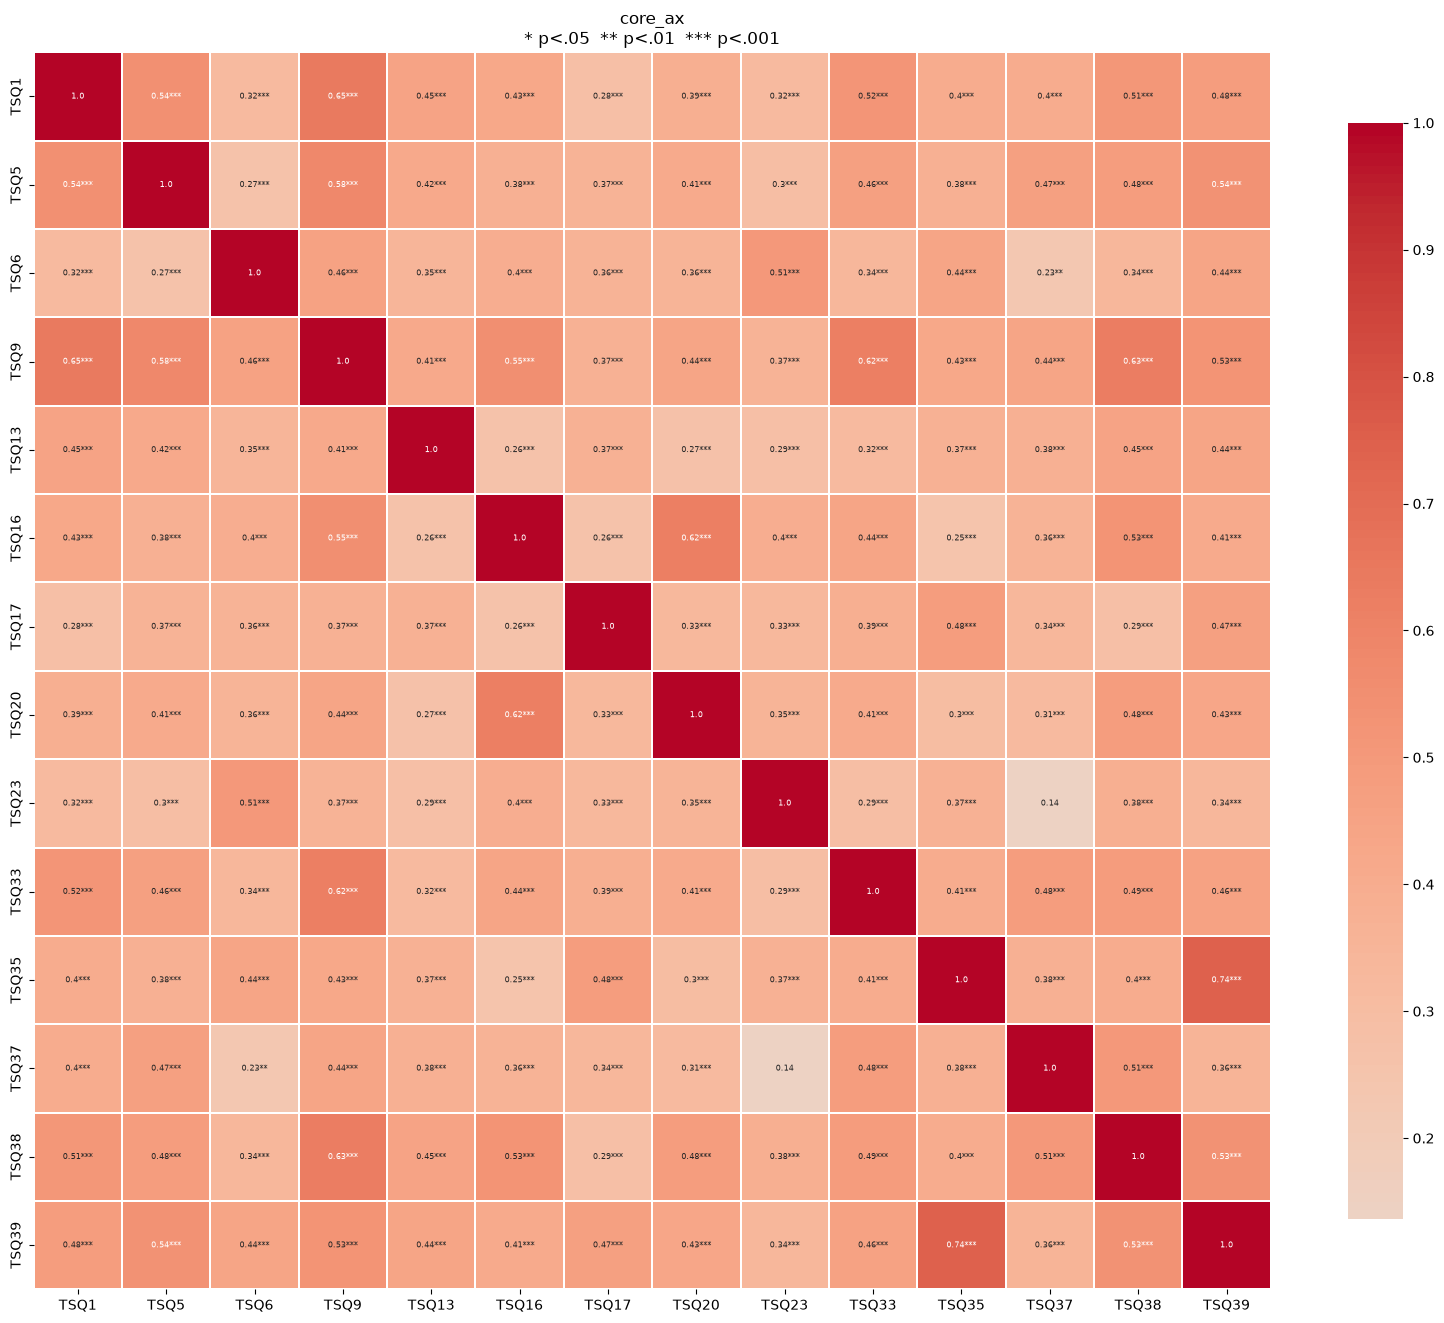

Items conservés (12/14) : ['TSQ1', 'TSQ5', 'TSQ6', 'TSQ13', 'TSQ16', 'TSQ17', 'TSQ20', 'TSQ23', 'TSQ33', 'TSQ35', 'TSQ37', 'TSQ38']
Items retirés (2) : ['TSQ9', 'TSQ39']

========================= core_sz =========================


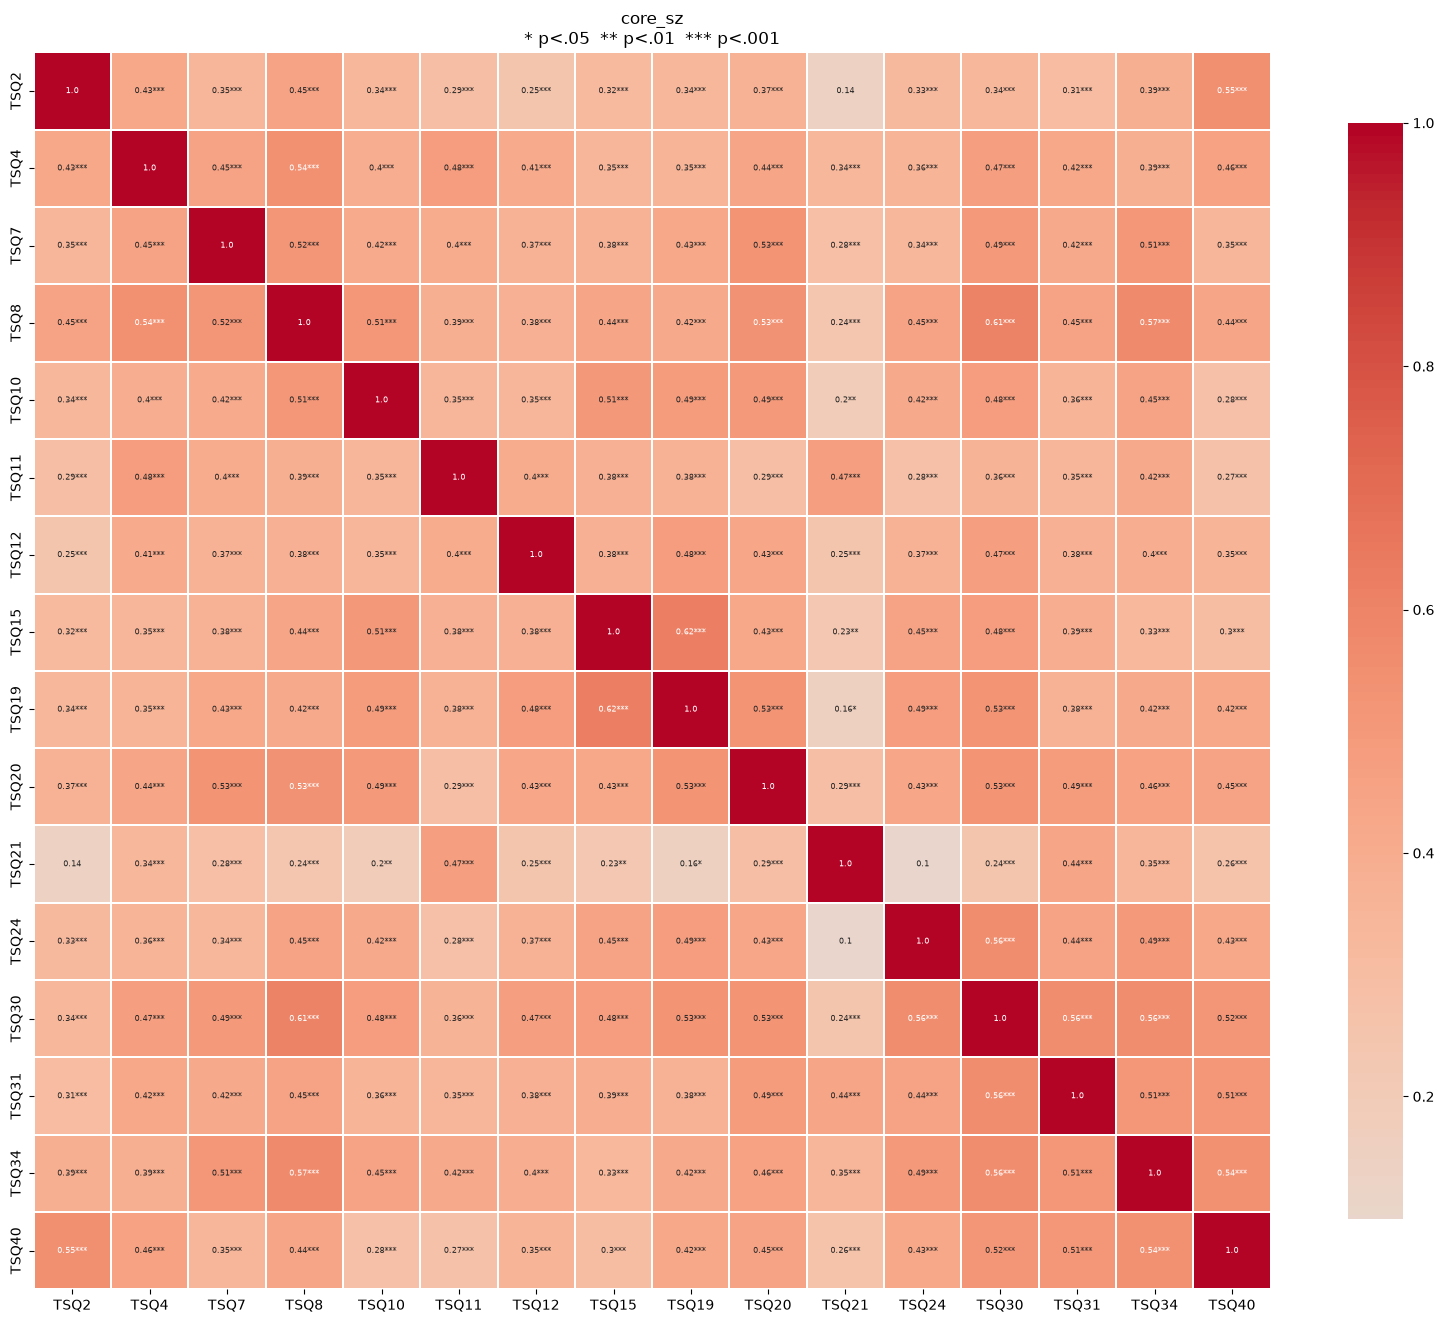

Items conservés (16/16) : ['TSQ2', 'TSQ4', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ15', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ24', 'TSQ30', 'TSQ31', 'TSQ34', 'TSQ40']
Items retirés (0) : []

========================= core_mdd =========================


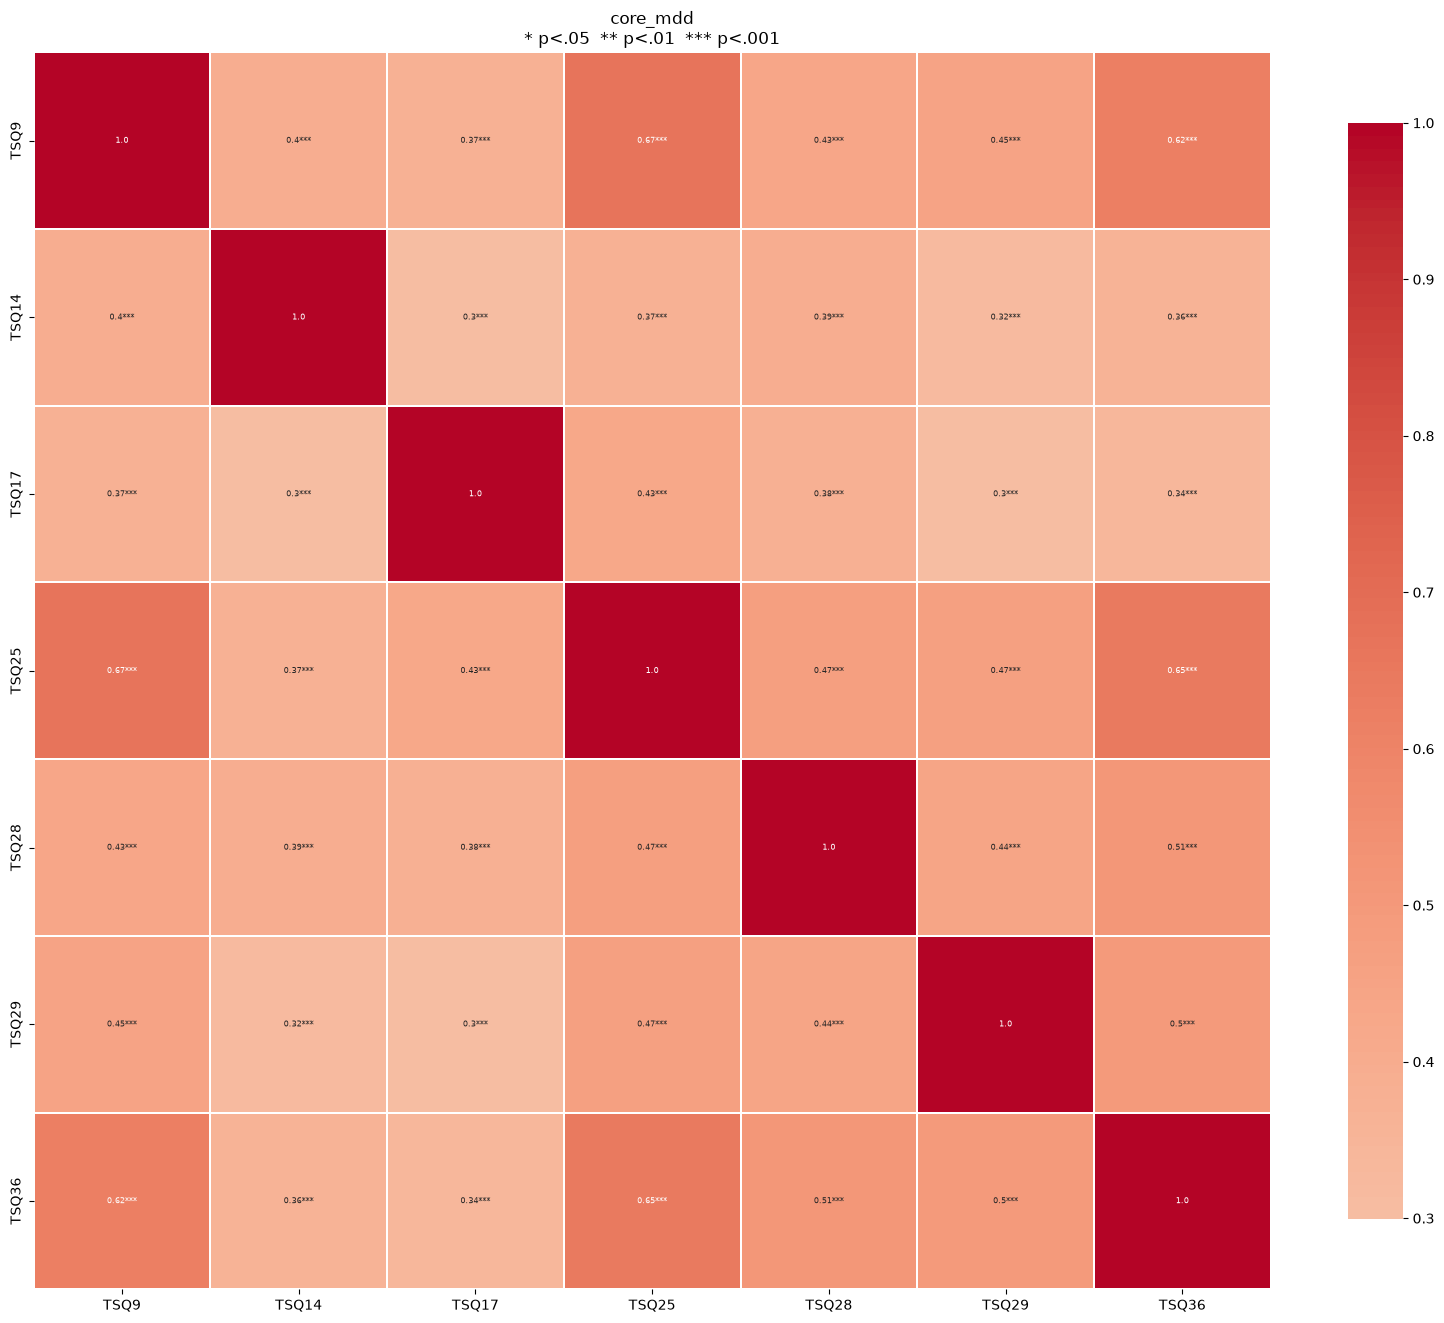

Items conservés (6/7) : ['TSQ9', 'TSQ14', 'TSQ17', 'TSQ28', 'TSQ29', 'TSQ36']
Items retirés (1) : ['TSQ25']

========================= core_man =========================


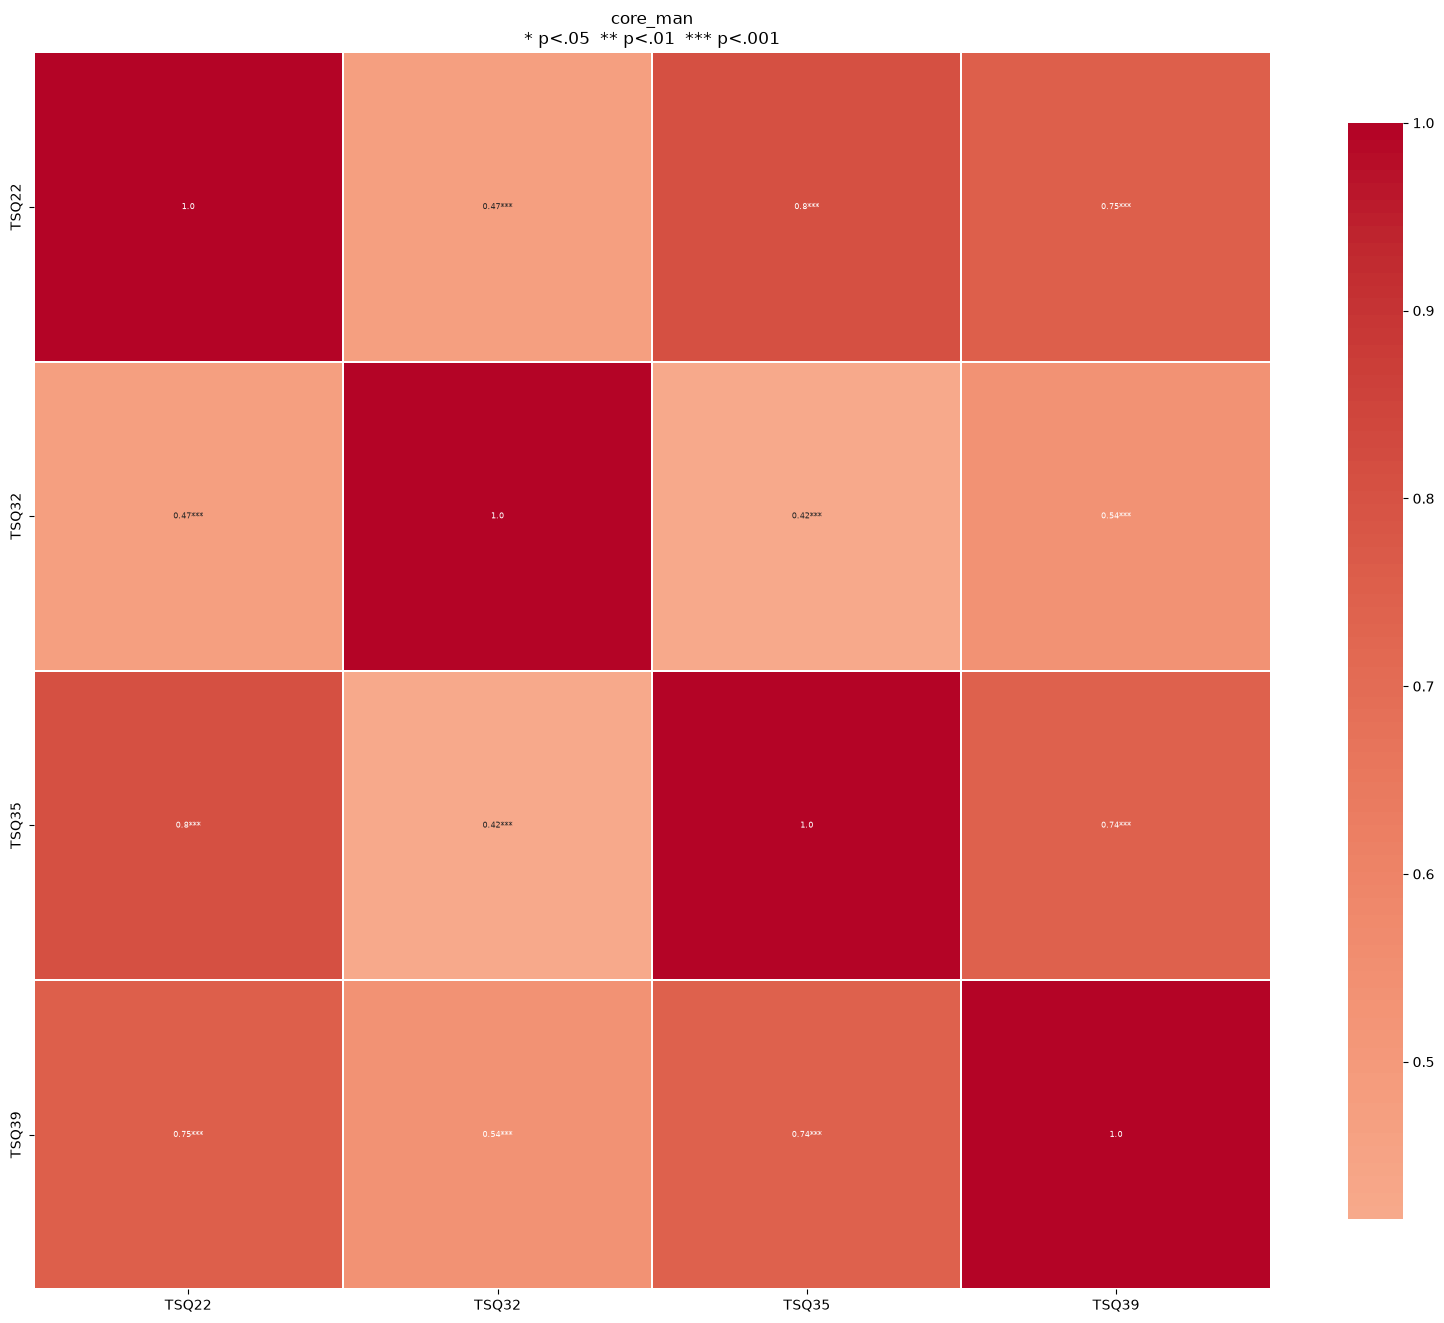

Items conservés (2/4) : ['TSQ32', 'TSQ35']
Items retirés (2) : ['TSQ22', 'TSQ39']

========================= core_ptsd =========================


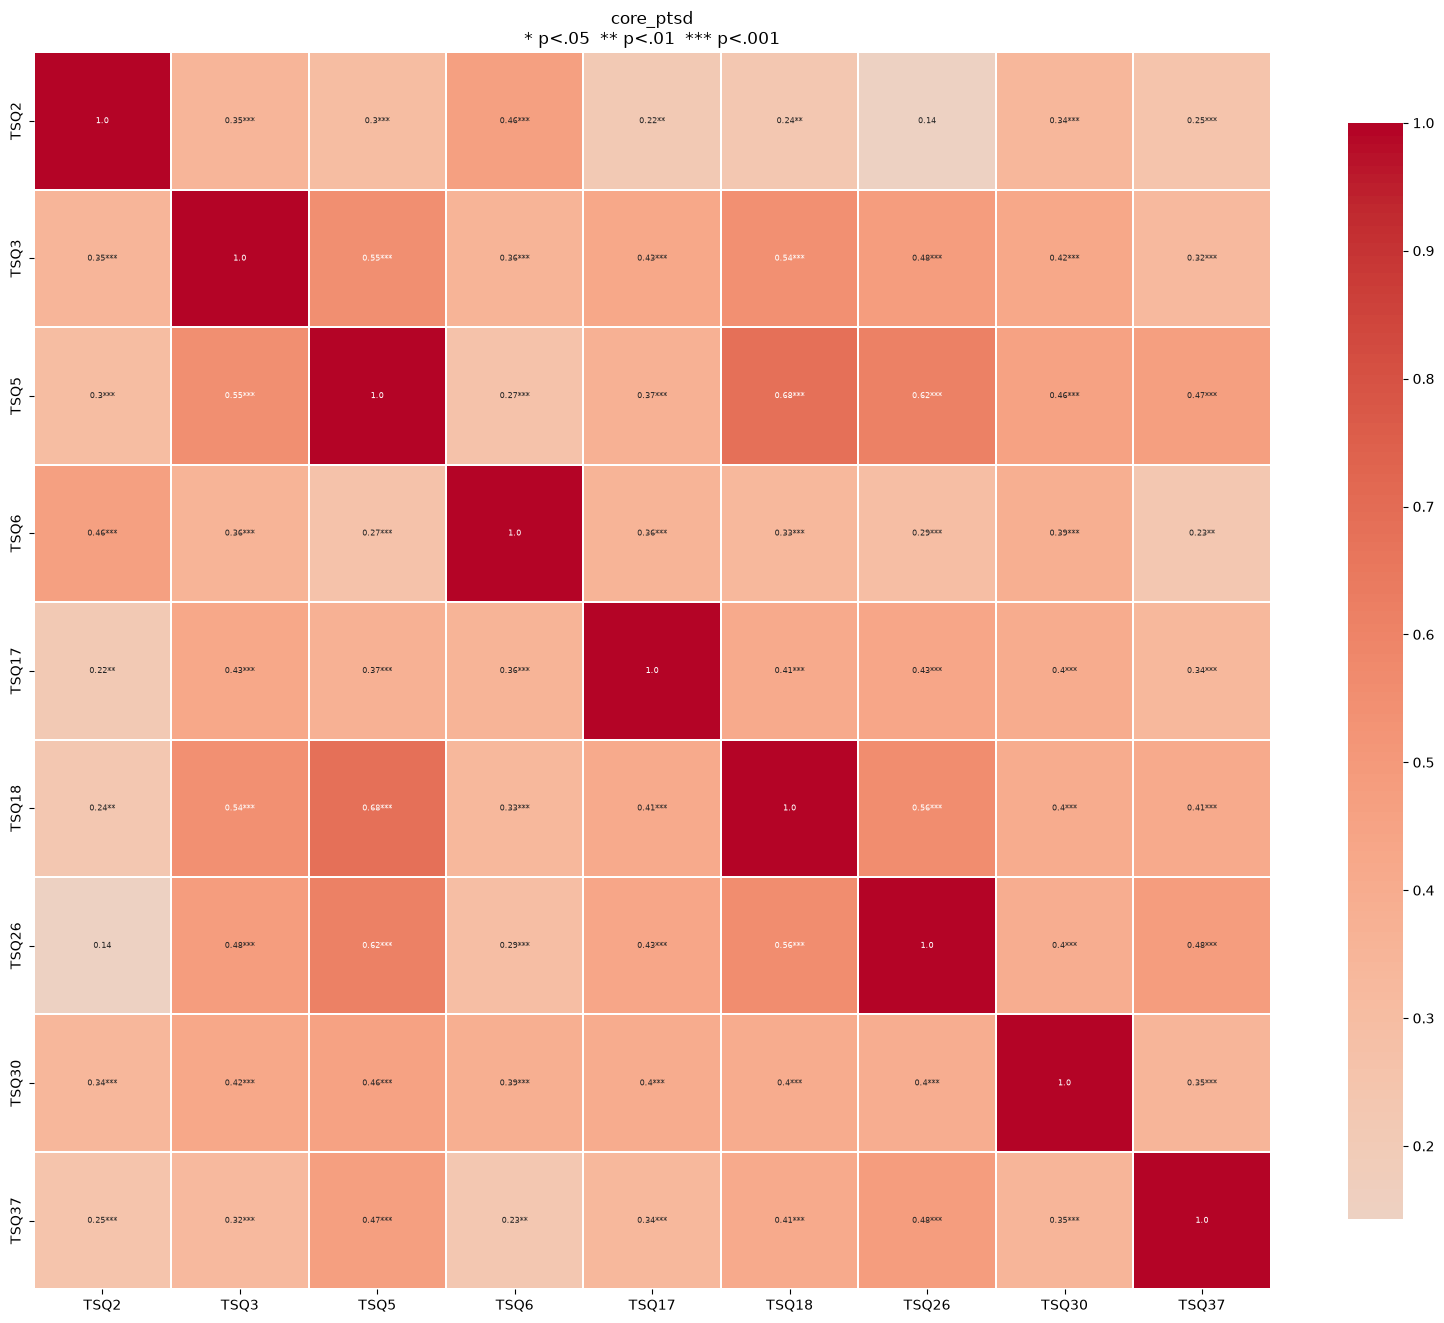

Items conservés (8/9) : ['TSQ2', 'TSQ3', 'TSQ6', 'TSQ17', 'TSQ18', 'TSQ26', 'TSQ30', 'TSQ37']
Items retirés (1) : ['TSQ5']

========================= periph_ax =========================


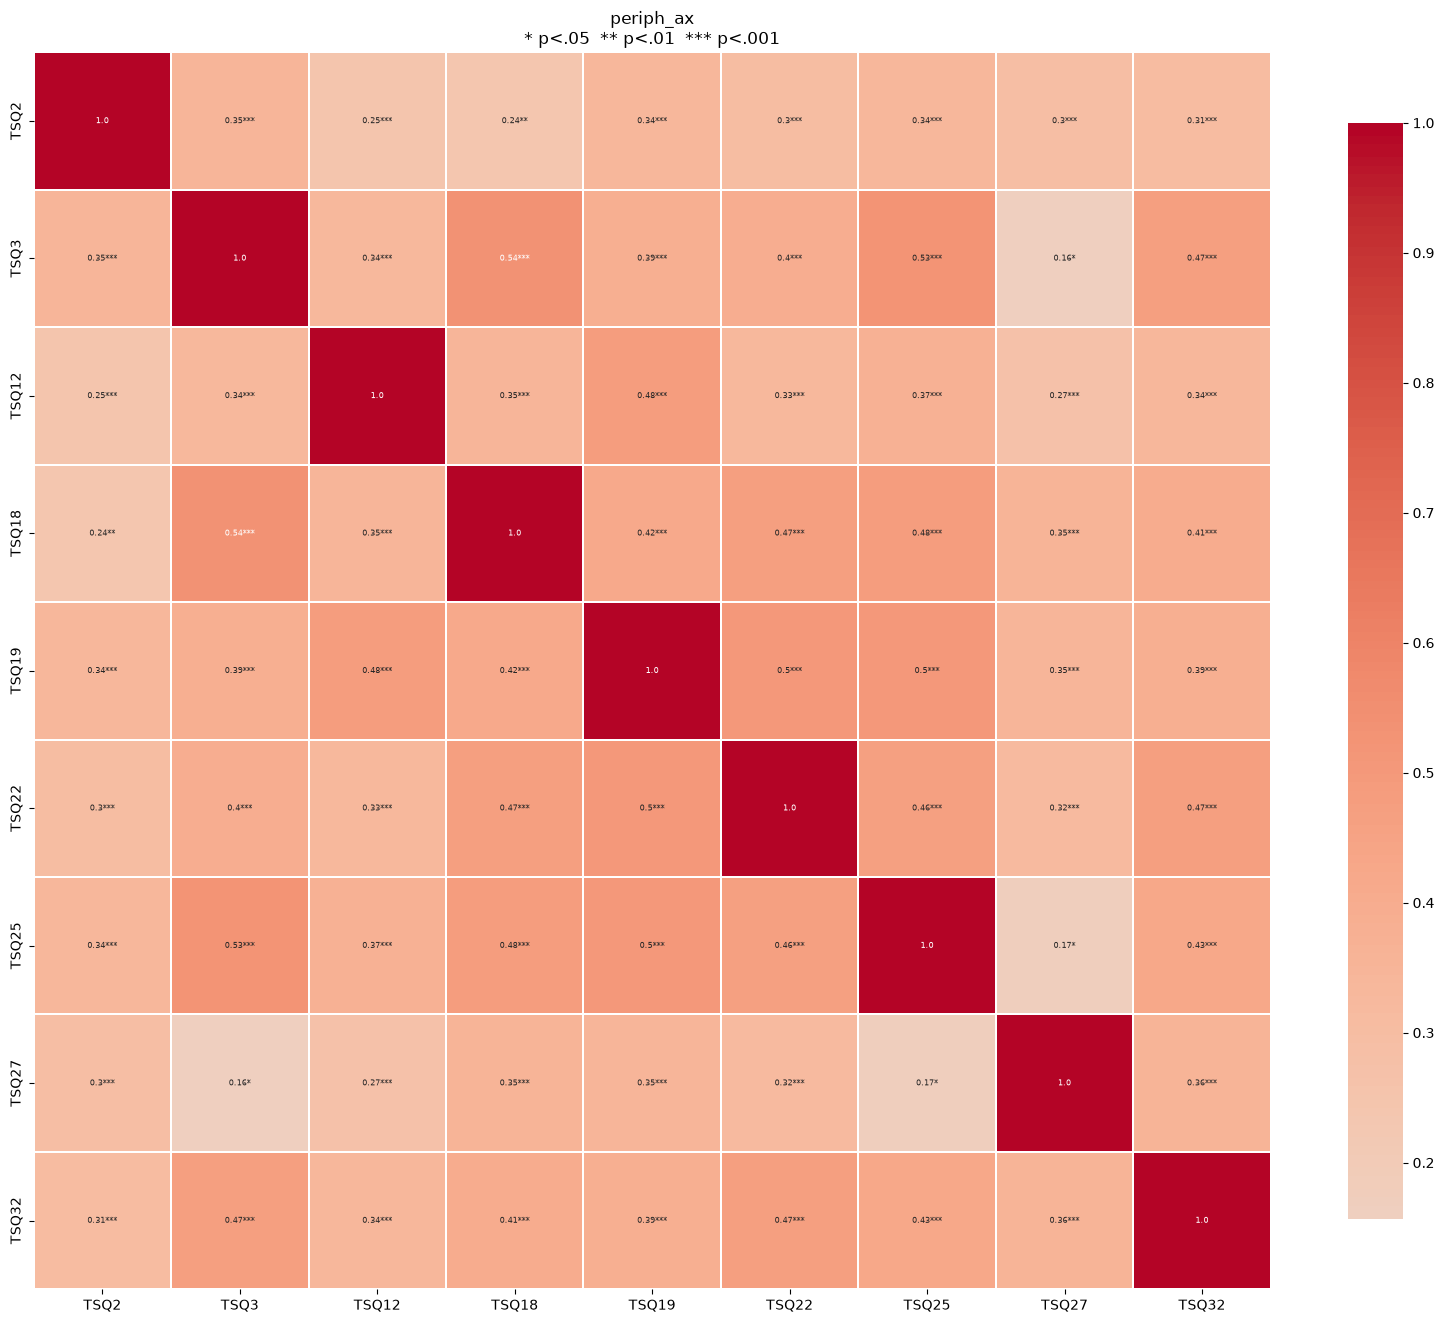

Items conservés (9/9) : ['TSQ2', 'TSQ3', 'TSQ12', 'TSQ18', 'TSQ19', 'TSQ22', 'TSQ25', 'TSQ27', 'TSQ32']
Items retirés (0) : []

========================= periph_sz =========================


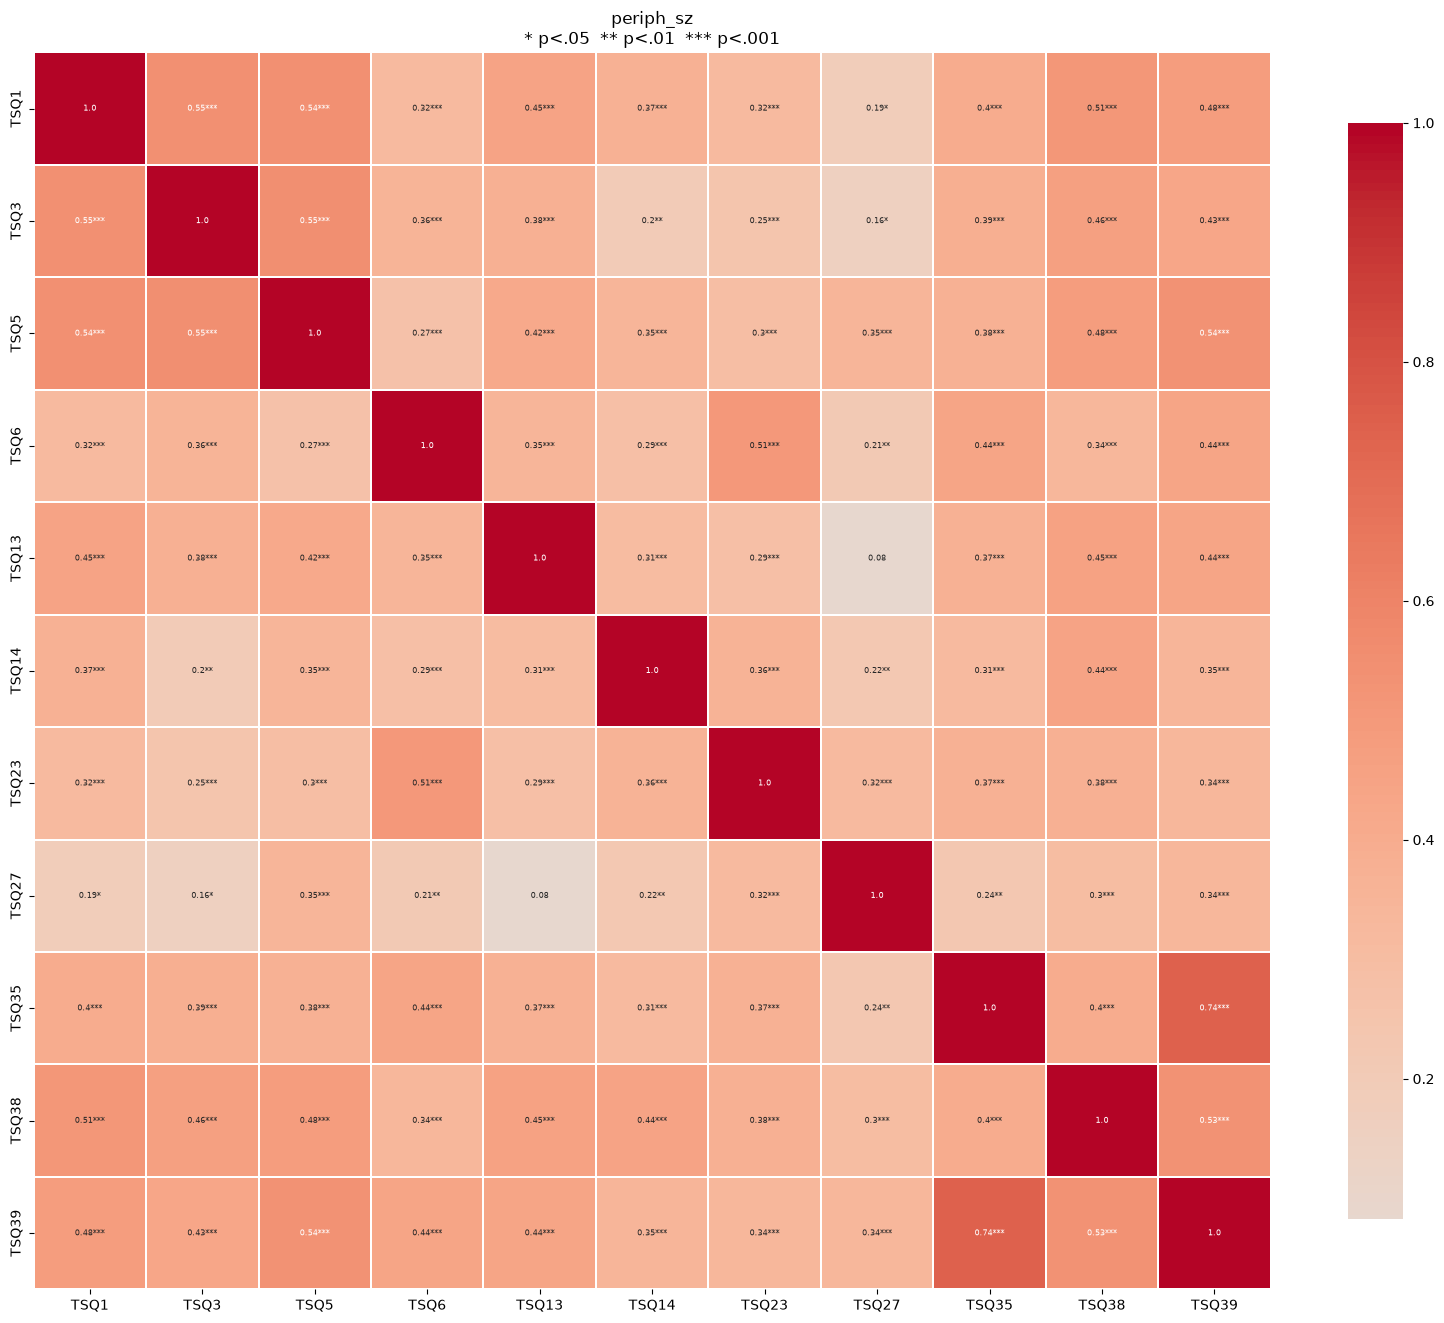

Items conservés (10/11) : ['TSQ1', 'TSQ3', 'TSQ5', 'TSQ6', 'TSQ13', 'TSQ14', 'TSQ23', 'TSQ27', 'TSQ35', 'TSQ38']
Items retirés (1) : ['TSQ39']

========================= periph_mdd =========================


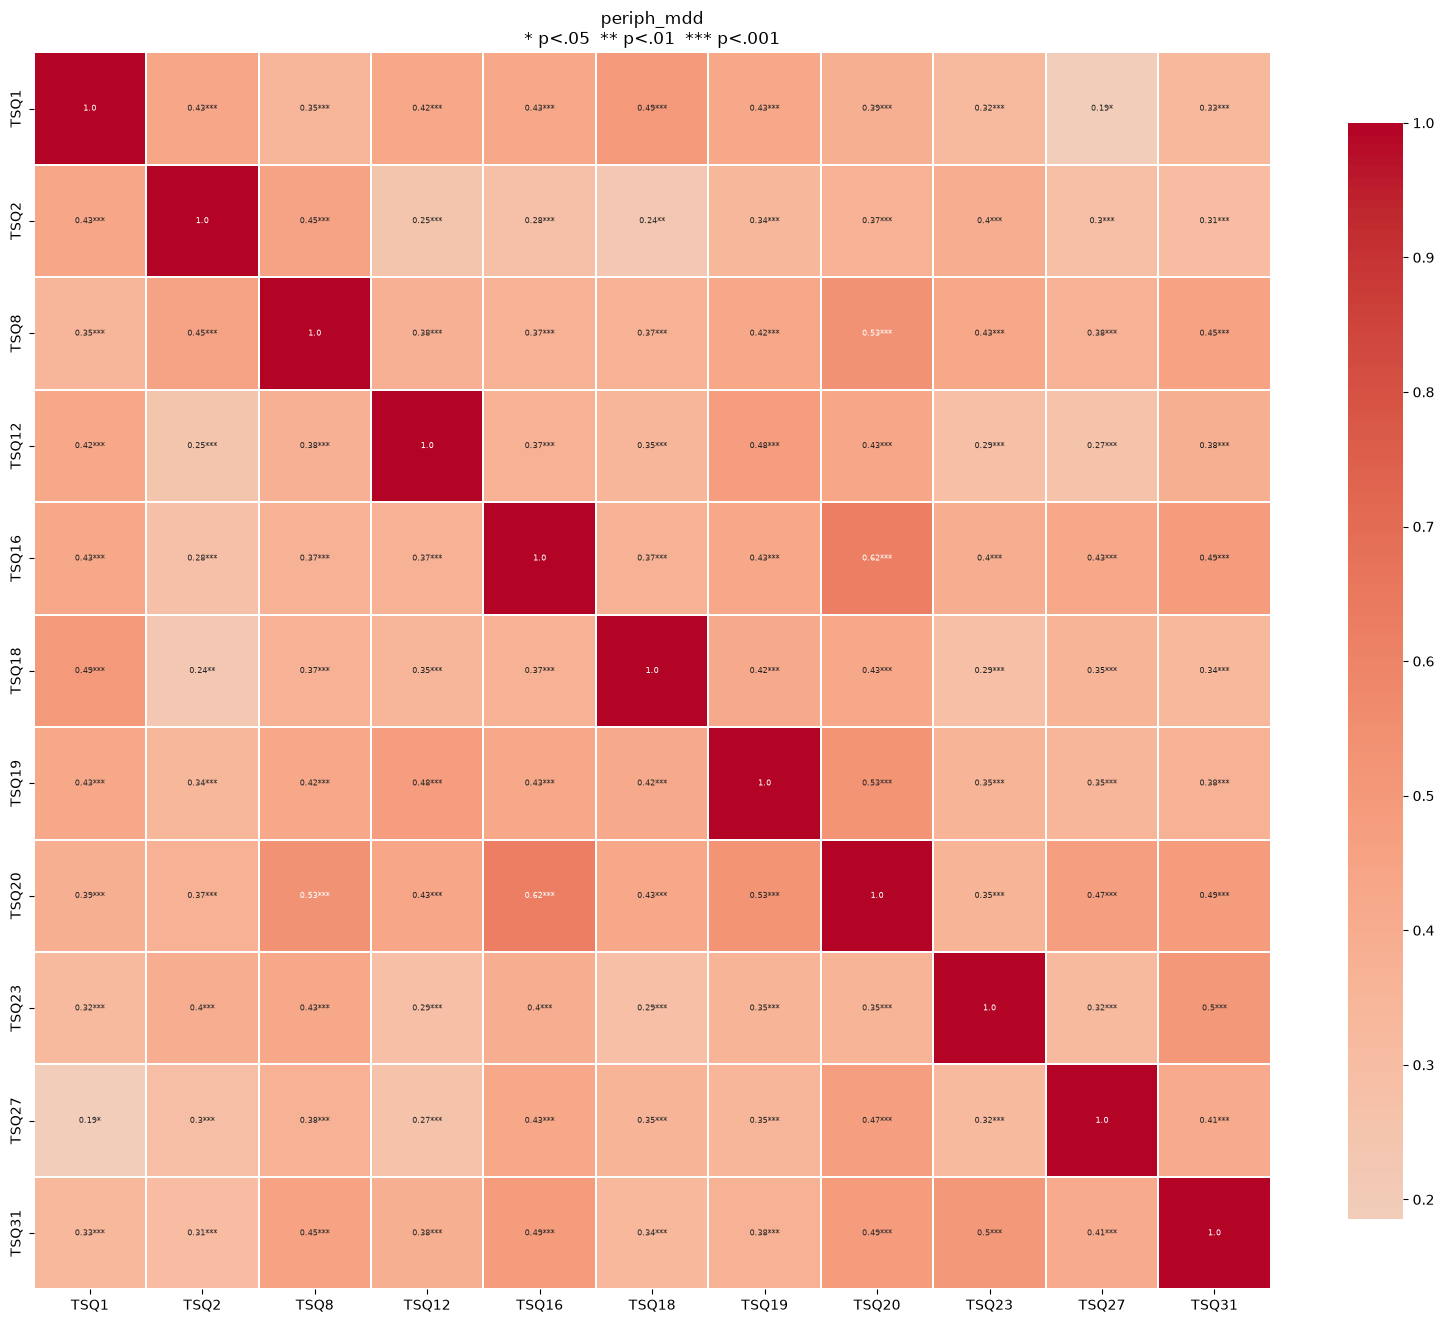

Items conservés (11/11) : ['TSQ1', 'TSQ2', 'TSQ8', 'TSQ12', 'TSQ16', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ23', 'TSQ27', 'TSQ31']
Items retirés (0) : []

========================= periph_man =========================


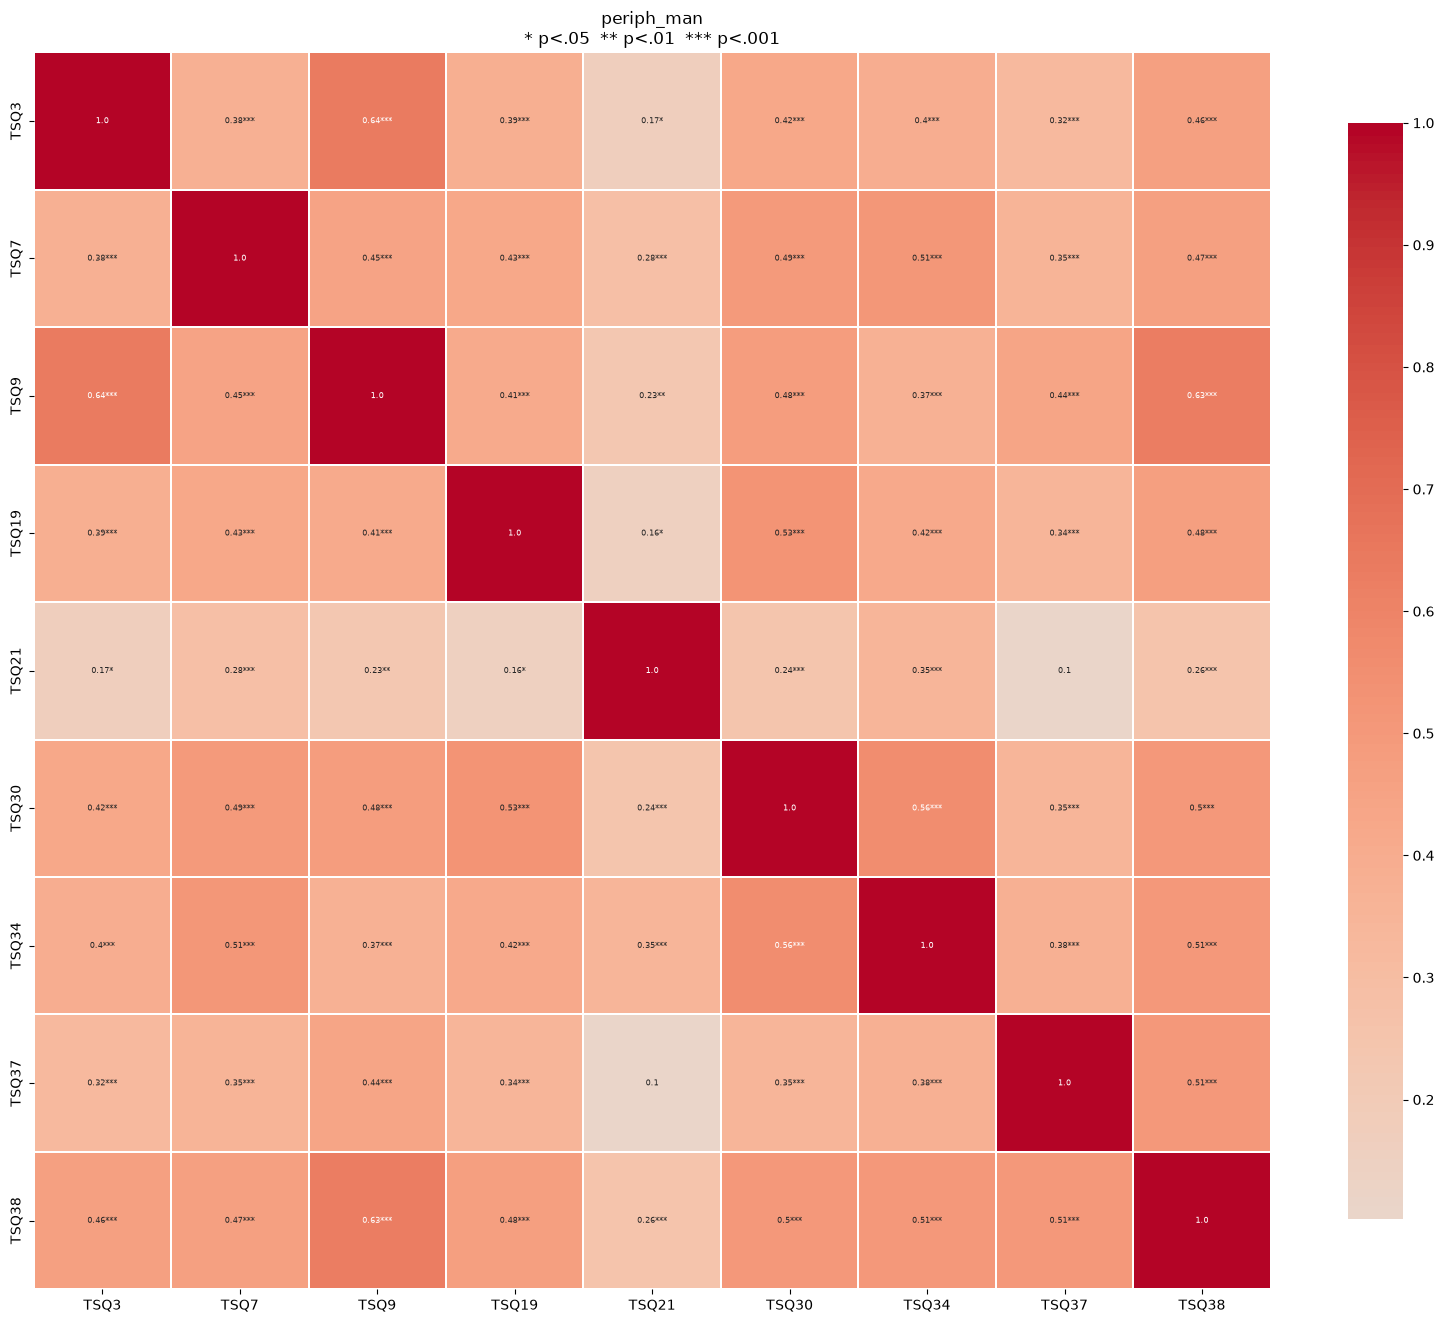

Items conservés (9/9) : ['TSQ3', 'TSQ7', 'TSQ9', 'TSQ19', 'TSQ21', 'TSQ30', 'TSQ34', 'TSQ37', 'TSQ38']
Items retirés (0) : []

========================= periph_ptsd =========================


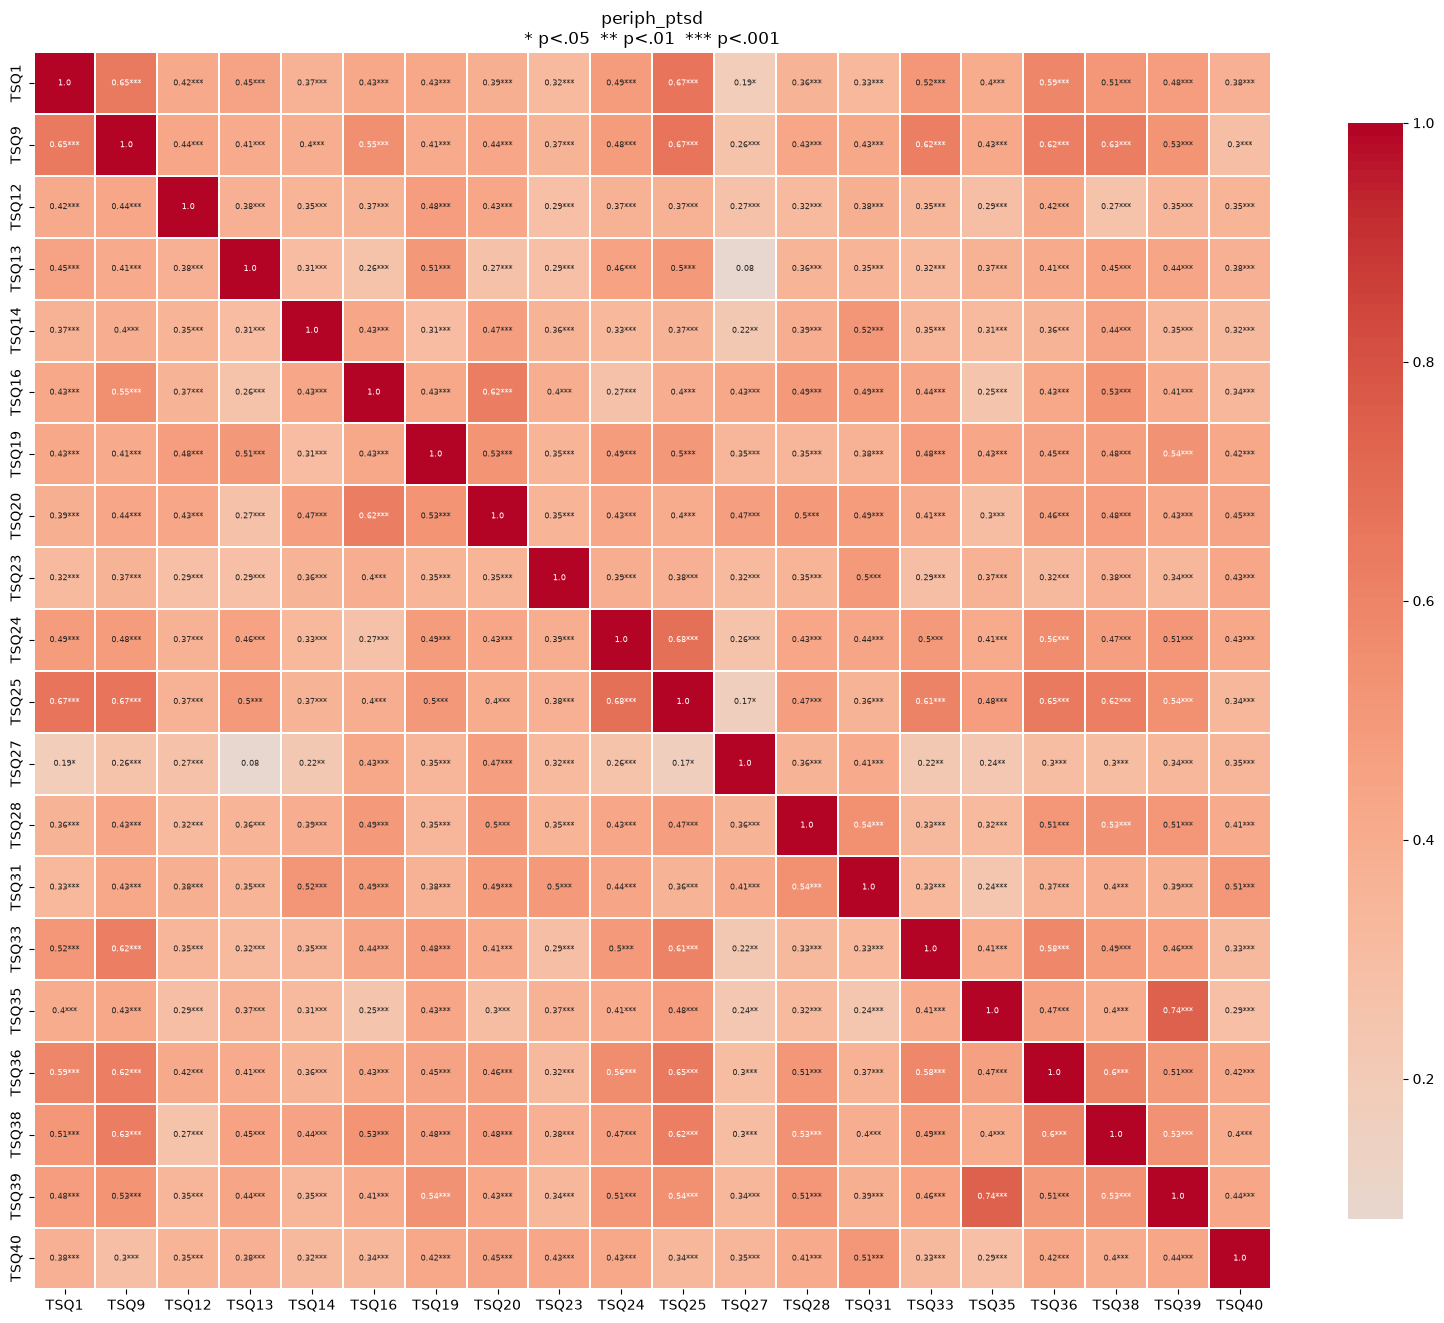

Items conservés (17/20) : ['TSQ1', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ16', 'TSQ19', 'TSQ20', 'TSQ23', 'TSQ24', 'TSQ27', 'TSQ28', 'TSQ31', 'TSQ33', 'TSQ35', 'TSQ36', 'TSQ38', 'TSQ40']
Items retirés (3) : ['TSQ9', 'TSQ25', 'TSQ39']


In [ ]:
from correl_TSQ import compute_tsq_corr, reduce_correlated_features

resultats_corr = {}

for nom, df_subset in sous_echelles.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    items = list(df_subset.columns)

    # Matrice de corrélation + heatmap pour chq sous-échelle
    compute_tsq_corr(df_all, items=items, title=nom)

    # greedy glouton pour enlever kes items qui covarient entre eux, pour chq sous echelle
    selected_items = reduce_correlated_features(df_all, items, threshold=0.65)
    dropped_items = [i for i in items if i not in selected_items]

    print(f"Items conservés ({len(selected_items)}/{len(items)}) :", selected_items)
    print(f"Items retirés ({len(dropped_items)}) :", dropped_items)

    resultats_corr[nom] = {
        "items_initiaux": items,
        "selected_items": selected_items,
        "dropped_items": dropped_items,
    }

In [36]:
sous_echelles_red = {}
sous_echelles_PD_red = {}

for nom, df_sains in sous_echelles.items():
    dropped = resultats_corr[nom]["dropped_items"] + ["score_total"]

    df_sains_red = df_sains.drop(columns=dropped, errors="ignore")
    df_pd_red = sous_echelles_PD[f"{nom}_PD"].drop(columns=dropped, errors="ignore")

    sous_echelles_red[nom] = df_sains_red
    sous_echelles_PD_red[f"{nom}_PD"] = df_pd_red

    print(f"{nom}: {df_sains.shape[1]} → {df_sains_red.shape[1]} items "
          f"(retirés: {dropped if dropped else 'aucun'})")

core_ax: 14 → 12 items (retirés: ['TSQ9', 'TSQ39', 'score_total'])
core_sz: 16 → 16 items (retirés: ['score_total'])
core_mdd: 7 → 6 items (retirés: ['TSQ25', 'score_total'])
core_man: 4 → 2 items (retirés: ['TSQ22', 'TSQ39', 'score_total'])
core_ptsd: 9 → 8 items (retirés: ['TSQ5', 'score_total'])
periph_ax: 9 → 9 items (retirés: ['score_total'])
periph_sz: 11 → 10 items (retirés: ['TSQ39', 'score_total'])
periph_mdd: 11 → 11 items (retirés: ['score_total'])
periph_man: 9 → 9 items (retirés: ['score_total'])
periph_ptsd: 20 → 17 items (retirés: ['TSQ9', 'TSQ25', 'TSQ39', 'score_total'])



========================= core_ax =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    69
1    69
Name: count, dtype: int64
Cluster 0: 69 participants (group 0: 60, group 1: 9)
Cluster 1: 69 participants (group 0: 53, group 1: 16)

=== Répartition train (fit) ===
0    69
1    69
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    32
1    15
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__penalty': 'l2'}
Meilleur score CV : 0.935
Score sur test set : 0.935

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__gamma': 'scale'}
Meilleur score CV : 0.942
Score sur test set : 0.967

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
Meilleur score CV : 0.942
Score sur test set : 0.967

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.935
Score sur test set : 0.967

=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.941758    0.966667
RandomForest          0.941758    0.966667
LogisticRegression    0.934615    0.935417
HistGradientBoosting  0.934615    0.966667

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.93      0.97        15

    accuracy                           0.98        47
   macro avg       0.98      0.97      0.98     

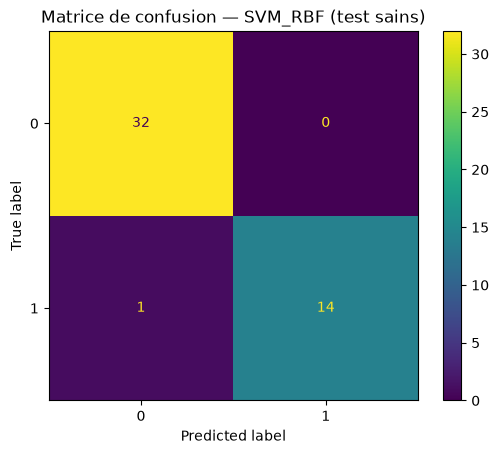

Meilleur modèle pour core_ax : SVM_RBF

========================= core_sz =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    95
1    43
Name: count, dtype: int64
Cluster 0: 95 participants (group 0: 82, group 1: 13)
Cluster 1: 43 participants (group 0: 31, group 1: 12)

=== Répartition train (fit) ===
0    95
1    43
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    35
1    12
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.936
Score sur test set : 0.958

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 'scale'}
Meilleur score CV : 0.936
Score sur test set : 0.971

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.924
Score sur test set : 0.958

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.924
Score sur test set : 0.958

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    0.935599    0.958333
SVM_RBF               0.935599    0.971429
RandomForest          0.924488    0.958333
HistGradientBoosting  0.924488    0.958333

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        35
           1       1.00      0.92      0.96        12

    accuracy                           0.98        47
   macro avg       0.99      0.96  

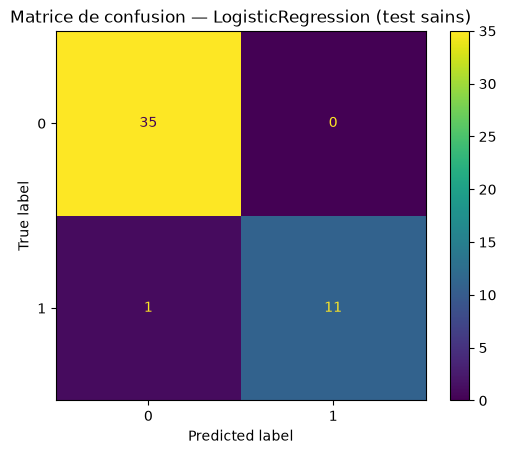

Meilleur modèle pour core_sz : LogisticRegression

========================= core_mdd =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    54
1    84
Name: count, dtype: int64
Cluster 0: 54 participants (group 0: 42, group 1: 12)
Cluster 1: 84 participants (group 0: 71, group 1: 13)

=== Répartition train (fit) ===
0    54
1    84
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    12
1    35
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.942
Score sur test set : 1.0

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__gamma': 'scale'}
Meilleur score CV : 0.947
Score sur test set : 1.0

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}
Meilleur score CV : 0.952
Score sur test set : 0.93

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__max_iter': 100}
Meilleur score CV : 0.954
Score sur test set : 0.971

=== Comparaison des modèles ===
                      CV score  Test score
HistGradientBoosting  0.953803    0.971429
RandomForest          0.951504    0.929762
SVM_RBF               0.946845    1.000000
LogisticRegression    0.941504    1.000000

Meilleur modèle : HistGradientBoosting
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.94      0.97        35

    accuracy                           0.96        47
   macro avg       0.93      0.97      0.

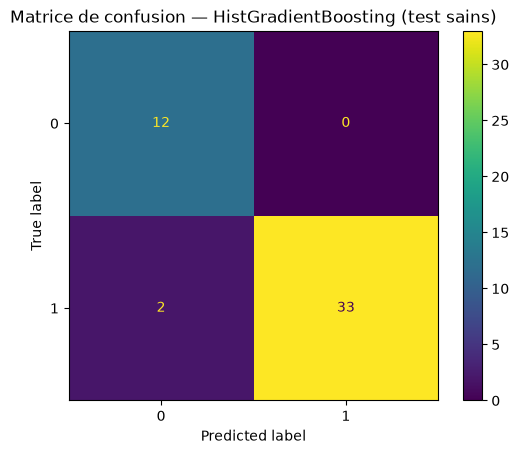

Meilleur modèle pour core_mdd : HistGradientBoosting

========================= core_man =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    71
1    67
Name: count, dtype: int64
Cluster 0: 71 participants (group 0: 59, group 1: 12)
Cluster 1: 67 participants (group 0: 54, group 1: 13)

=== Répartition train (fit) ===
0    71
1    67
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    29
1    18
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.809
Score sur test set : 0.813

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 1}
Meilleur score CV : 0.986
Score sur test set : 1.0

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
Meilleur score CV : 0.992
Score sur test set : 0.966

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.971
Score sur test set : 1.0

=== Comparaison des modèles ===
                      CV score  Test score
RandomForest          0.992308    0.965517
SVM_RBF               0.985714    1.000000
HistGradientBoosting  0.970879    1.000000
LogisticRegression    0.809194    0.813218

Meilleur modèle : RandomForest
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        29
           1       0.90      1.00      0.95        18

    accuracy                           0.96        47
   macro avg       0.95      0.97      0.96        

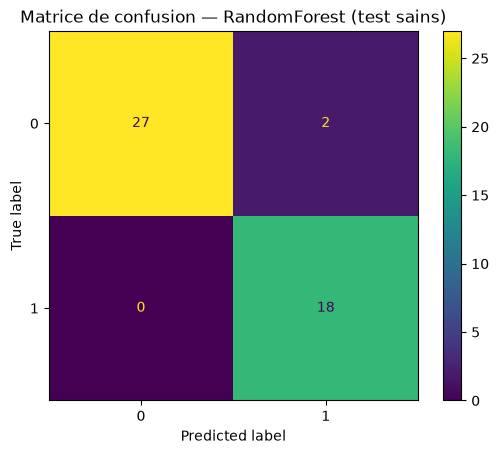

Meilleur modèle pour core_man : RandomForest

========================= core_ptsd =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    63
1    75
Name: count, dtype: int64
Cluster 0: 63 participants (group 0: 46, group 1: 17)
Cluster 1: 75 participants (group 0: 67, group 1: 8)

=== Répartition train (fit) ===
0    63
1    75
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    13
1    34
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.957
Score sur test set : 0.962

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__gamma': 1}
Meilleur score CV : 0.97
Score sur test set : 0.923

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.956
Score sur test set : 0.962

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.956
Score sur test set : 0.962

=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.970256    0.923077
LogisticRegression    0.956923    0.961538
RandomForest          0.955897    0.961538
HistGradientBoosting  0.955897    0.961538

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.94      1.00      0.97        34

    accuracy                           0.96        47
   macro avg       0.97      0.92      0.94        47
w

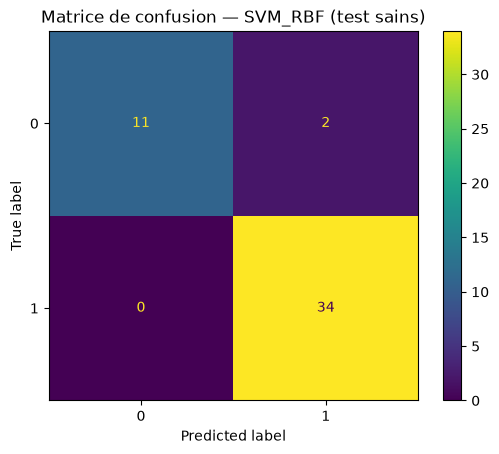

Meilleur modèle pour core_ptsd : SVM_RBF

========================= periph_ax =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    60
1    78
Name: count, dtype: int64
Cluster 0: 60 participants (group 0: 46, group 1: 14)
Cluster 1: 78 participants (group 0: 67, group 1: 11)

=== Répartition train (fit) ===
0    60
1    78
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    17
1    30
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.931
Score sur test set : 0.925

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__gamma': 0.1}
Meilleur score CV : 0.939
Score sur test set : 0.925

=== RandomForest ===
Meilleurs params : {'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.929
Score sur test set : 0.882

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.933
Score sur test set : 0.882

=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.939167    0.924510
HistGradientBoosting  0.932917    0.882353
LogisticRegression    0.930833    0.924510
RandomForest          0.929167    0.882353

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        17
           1       0.94      0.97      0.95        30

    accuracy                           0.94        47
   macro avg       0.94      0.92      0.93        47
w

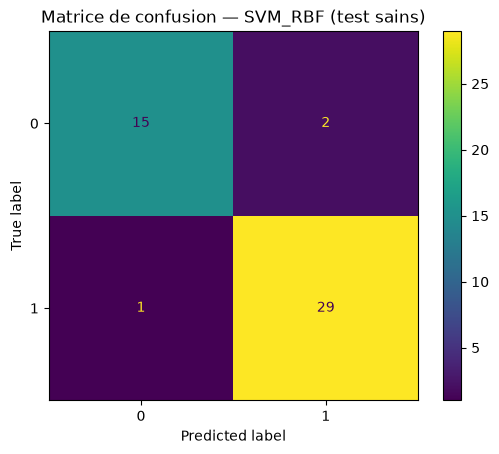

Meilleur modèle pour periph_ax : SVM_RBF

========================= periph_sz =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    67
1    71
Name: count, dtype: int64
Cluster 0: 67 participants (group 0: 50, group 1: 17)
Cluster 1: 71 participants (group 0: 63, group 1: 8)

=== Répartition train (fit) ===
0    67
1    71
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    18
1    29
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 0.01, 'clf__penalty': 'l2'}
Meilleur score CV : 0.936
Score sur test set : 0.833

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 0.1}
Meilleur score CV : 0.97
Score sur test set : 0.806

=== RandomForest ===
Meilleurs params : {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.949
Score sur test set : 0.861

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 200}
Meilleur score CV : 0.964
Score sur test set : 0.833

=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.970330    0.805556
HistGradientBoosting  0.963663    0.833333
RandomForest          0.949377    0.861111
LogisticRegression    0.935568    0.833333

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      0.61      0.76        18
           1       0.81      1.00      0.89        29

    accuracy                           0.85        47
   macro avg       0.90      0.81      0.83        47


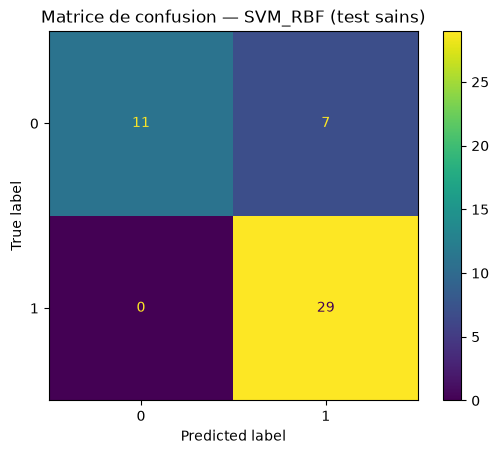

Meilleur modèle pour periph_sz : SVM_RBF

========================= periph_mdd =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    55
1    83
Name: count, dtype: int64
Cluster 0: 55 participants (group 0: 41, group 1: 14)
Cluster 1: 83 participants (group 0: 72, group 1: 11)

=== Répartition train (fit) ===
0    55
1    83
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    16
1    31
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.94
Score sur test set : 0.844

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 'scale'}
Meilleur score CV : 0.951
Score sur test set : 0.812

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.927
Score sur test set : 0.688

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.93
Score sur test set : 0.75

=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.951303     0.81250
LogisticRegression    0.939539     0.84375
HistGradientBoosting  0.930281     0.75000
RandomForest          0.927440     0.68750

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      0.62      0.77        16
           1       0.84      1.00      0.91        31

    accuracy                           0.87        47
   macro avg       0.92      0.81      0.84     

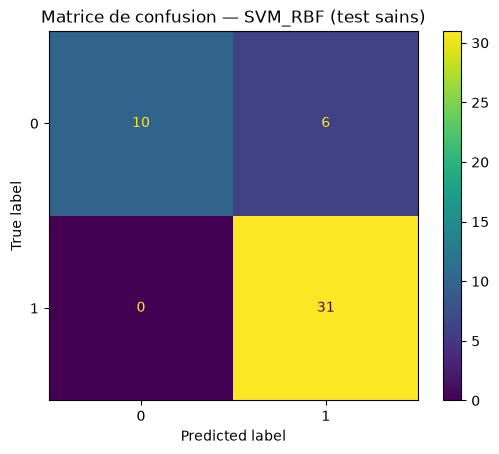

Meilleur modèle pour periph_mdd : SVM_RBF

========================= periph_man =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    78
1    60
Name: count, dtype: int64
Cluster 0: 78 participants (group 0: 68, group 1: 10)
Cluster 1: 60 participants (group 0: 45, group 1: 15)

=== Répartition train (fit) ===
0    78
1    60
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    31
1    16
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.977
Score sur test set : 0.969

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 1}
Meilleur score CV : 0.977
Score sur test set : 0.844

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.972
Score sur test set : 0.969

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.965
Score sur test set : 0.969

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    0.976667     0.96875
SVM_RBF               0.976667     0.84375
RandomForest          0.972083     0.96875
HistGradientBoosting  0.965417     0.96875

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      0.94      0.97        16

    accuracy                           0.98        47
   macro avg       0.98      0.97      0.

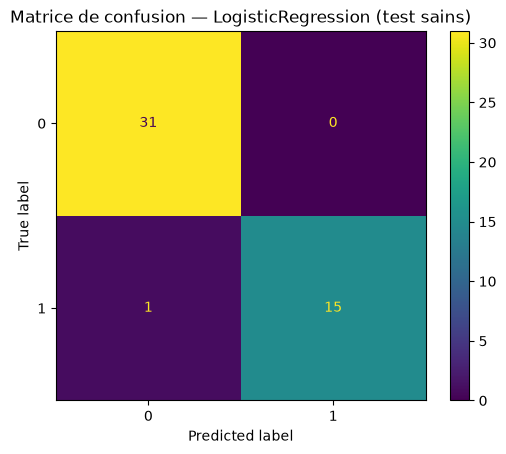

Meilleur modèle pour periph_man : LogisticRegression

========================= periph_ptsd =========================


c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    62
1    76
Name: count, dtype: int64
Cluster 0: 62 participants (group 0: 46, group 1: 16)
Cluster 1: 76 participants (group 0: 67, group 1: 9)

=== Répartition train (fit) ===
0    62
1    76
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    18
1    29
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.979
Score sur test set : 0.889

=== SVM_RBF ===


c:\TSQ\data\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 0.1, 'clf__gamma': 'scale'}
Meilleur score CV : 0.974
Score sur test set : 0.917

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.965
Score sur test set : 0.889

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.956
Score sur test set : 0.889

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    0.979167    0.888889
SVM_RBF               0.974167    0.916667
RandomForest          0.965449    0.888889
HistGradientBoosting  0.956474    0.888889

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.78      0.88        18
           1       0.88      1.00      0.94        29

    accuracy                           0.91        47
   macro avg       0.94      0.89  

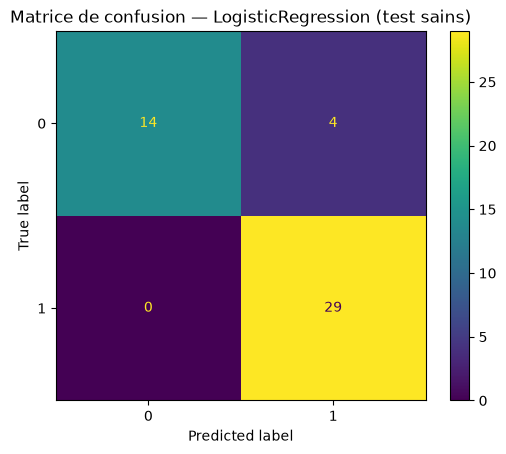

Meilleur modèle pour periph_ptsd : LogisticRegression


In [ ]:
from testclust import split_umap_clustering_train_test
from pipeline_ML import train_and_compare_classifiers, apply_to_patients

resultats_sous_echelles = {}

for nom, df_sains in sous_echelles_red.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    split_result = split_umap_clustering_train_test(
        df_sains, n_clusters=2, test_size=0.25, random_state=42, group=group,
    )

    X_train, X_test = split_result["X_train_2d"], split_result["X_test_2d"]
    y_train, y_test = split_result["y_train"], split_result["y_test"]

    results, summary, best_model_name, best_model = train_and_compare_classifiers(
        X_train, y_train, X_test, y_test,
        scoring="balanced_accuracy",
        plot_curves=False,   
    )

    resultats_sous_echelles[nom] = {
        "split_result": split_result,
        "results": results,
        "summary": summary,
        "best_model_name": best_model_name,
        "best_model": best_model,
    }

    print(f"Meilleur modèle pour {nom} : {best_model_name}")

In [38]:
recap = []
for nom, r in resultats_sous_echelles.items():
    best_row = r["summary"].loc[r["best_model_name"]]
    recap.append({
        "sous_echelle": nom,
        "n_items": r["split_result"]["df_train"].shape[1] - (1 if "group" in r["split_result"]["df_train"].columns else 0),
        "best_model": r["best_model_name"],
        "cv_score": round(best_row["CV score"], 3),
        "test_score": round(best_row["Test score"], 3),
    })

df_recap = pd.DataFrame(recap).sort_values("test_score", ascending=False)
df_recap

,sous_echelle,n_items,best_model,cv_score,test_score
2,core_mdd,6,HistGradientBoosting,0.954,0.971
8,periph_man,9,LogisticRegression,0.977,0.969
0,core_ax,12,SVM_RBF,0.942,0.967
3,core_man,2,RandomForest,0.992,0.966
1,core_sz,16,LogisticRegression,0.936,0.958
5,periph_ax,9,SVM_RBF,0.939,0.925
4,core_ptsd,8,SVM_RBF,0.970,0.923
9,periph_ptsd,17,LogisticRegression,0.979,0.889
7,periph_mdd,11,SVM_RBF,0.951,0.812
6,periph_sz,10,SVM_RBF,0.970,0.806


In [39]:
from pipeline_ML import apply_to_patients

for nom, r in resultats_sous_echelles.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    df_patients = sous_echelles_PD_red[f"{nom}_PD"]

    df_patients_pred = apply_to_patients(
        r["best_model"],
        r["split_result"]["res_train"].umap_2d_model,   # fit sur train, jamais sur test ni patients
        df_patients,
    )

    r["df_patients_pred"] = df_patients_pred   # stocké dans le dict pour usage/recap ultérieur

    print(df_patients_pred["predicted_cluster"].value_counts().sort_index())


========================= core_ax =========================
predicted_cluster
0    14
1    17
Name: count, dtype: int64

========================= core_sz =========================
predicted_cluster
0    17
1    14
Name: count, dtype: int64

========================= core_mdd =========================
predicted_cluster
0    17
1    14
Name: count, dtype: int64

========================= core_man =========================
predicted_cluster
0    14
1    17
Name: count, dtype: int64

========================= core_ptsd =========================
predicted_cluster
0    17
1    14
Name: count, dtype: int64

========================= periph_ax =========================
predicted_cluster
0    18
1    13
Name: count, dtype: int64

========================= periph_sz =========================
predicted_cluster
0    17
1    14
Name: count, dtype: int64

========================= periph_mdd =========================
predicted_cluster
0    15
1    16
Name: count, dtype: int64

====================

# Récap des meilleurs modeles trouvés pour chq sous echelle

In [40]:
recap = []
for nom, r in resultats_sous_echelles.items():
    best_row = r["summary"].loc[r["best_model_name"]]
    patient_counts = r["df_patients_pred"]["predicted_cluster"].value_counts().sort_index()
    recap.append({
        "sous_echelle": nom,
        "best_model": r["best_model_name"],
        "cv_score": round(best_row["CV score"], 3),
        "test_score": round(best_row["Test score"], 3),
        "patients_cluster_0": patient_counts.get(0, 0),
        "patients_cluster_1": patient_counts.get(1, 0),
    })

df_recap = pd.DataFrame(recap).sort_values("test_score", ascending=False)
df_recap

,sous_echelle,best_model,cv_score,test_score,patients_cluster_0,patients_cluster_1
2,core_mdd,HistGradientBoosting,0.954,0.971,17,14
8,periph_man,LogisticRegression,0.977,0.969,12,19
0,core_ax,SVM_RBF,0.942,0.967,14,17
3,core_man,RandomForest,0.992,0.966,14,17
1,core_sz,LogisticRegression,0.936,0.958,17,14
5,periph_ax,SVM_RBF,0.939,0.925,18,13
4,core_ptsd,SVM_RBF,0.970,0.923,17,14
9,periph_ptsd,LogisticRegression,0.979,0.889,20,11
7,periph_mdd,SVM_RBF,0.951,0.812,15,16
6,periph_sz,SVM_RBF,0.970,0.806,17,14


# Visualisation de la classification des participants avec diag dans l'espace UMAP

In [41]:
import pandas as pd
import plotly.express as px

for nom, r in resultats_sous_echelles.items():
    split_result = r["split_result"]
    res_train = split_result["res_train"]
    df_patients_pred = r["df_patients_pred"]
    df_patients = sous_echelles_PD_red[f"{nom}_PD"]

    X_patients_umap = res_train.umap_2d_model.transform(df_patients.values)

    hover_train = [f"Participant {i}" for i in split_result["df_train"].index]
    hover_test  = [f"Participant {i}" for i in split_result["df_test"].index]
    hover_diag  = [f"Participant {i}" for i in df_patients.index]

    df_plot = pd.concat([
        pd.DataFrame({
            "x": split_result["X_train_2d"][:, 0], "y": split_result["X_train_2d"][:, 1],
            "cluster": split_result["y_train"].astype(str),
            "type": "Sains (train)",
            "participant": hover_train,
        }),
        pd.DataFrame({
            "x": split_result["X_test_2d"][:, 0], "y": split_result["X_test_2d"][:, 1],
            "cluster": split_result["y_test"].astype(str),
            "type": "Sains (test)",
            "participant": hover_test,
        }),
        pd.DataFrame({
            "x": X_patients_umap[:, 0], "y": X_patients_umap[:, 1],
            "cluster": df_patients_pred["predicted_cluster"].astype(str),
            "type": "Diag",
            "participant": hover_diag,
        }),
    ], ignore_index=True)

    fig = px.scatter(
        df_plot, x="x", y="y",
        color="cluster", symbol="type",
        color_discrete_map={"0": "#A777F1", "1": "#FC6955"},
        symbol_map={"Sains (train)": "circle", "Sains (test)": "circle-open", "Diag": "triangle-up"},
        opacity=0.7,
        hover_name="participant",
        title=f"{nom} — Sains (train/test) et patients projetés dans l'espace UMAP (fit sur train)",
    )

    for trace in fig.data:
        if "Diag" in trace.name:
            trace.marker.line = dict(width=1, color="black")

    fig.show(renderer="browser")

# Regardons si le profil des participants avec diag mis dans le cluster 1 correspond à leur diag en fonction des sous echelles

In [45]:
col_name = df_PD.columns[18]
print(f"Colonne diag : {col_name}")

diag = df_PD[col_name]   # Series indexée par participant

repartition_patients = {}

for nom, r in resultats_sous_echelles.items():
    df_patients_pred = r["df_patients_pred"]

    cluster_0_idx = df_patients_pred[df_patients_pred["predicted_cluster"] == 0].index
    cluster_1_idx = df_patients_pred[df_patients_pred["predicted_cluster"] == 1].index

    cluster_0 = list(zip(cluster_0_idx, diag.reindex(cluster_0_idx)))
    cluster_1 = list(zip(cluster_1_idx, diag.reindex(cluster_1_idx)))

    repartition_patients[nom] = {
        "cluster_0": cluster_0,
        "cluster_1": cluster_1,
    }

    print(f"\n{'='*25} {nom} {'='*25}")
    print(f"Cluster 0 ({len(cluster_0)} patients) :")
    for participant, d in cluster_0:
        print(f"  Participant {participant} → {d}")
    print(f"Cluster 1 ({len(cluster_1)} patients) :")
    for participant, d in cluster_1:
        print(f"  Participant {participant} → {d}")

Colonne diag : Si oui, lequel (lesquels) ? 

========================= core_ax =========================
Cluster 0 (14 patients) :
  Participant 2 → TDAH
Dépression
Anxiété chronique
  Participant 11 → Depression
  Participant 20 → TROUBLE BIPOLAIRE TYPE 1
  Participant 41 → épisode dépressif
  Participant 79 → Tendance depressive
  Participant 98 → Dépression
  Participant 139 → Schizophrénie
  Participant 153 → Trouble anxieux généralisé
  Participant 257 → TOC
  Participant 266 → Anxiété généralisée
  Participant 287 → borderline
  Participant 296 → Depression reactionnelle
  Participant 300 → Bipolarité
  Participant 310 → Bipolarité
Cluster 1 (17 patients) :
  Participant 4 → Trouble anxieux
  Participant 13 → Dépression
  Participant 28 → épisode dépressif caractérisé
  Participant 113 → Dépression
  Participant 140 → Dépression, anxiété, TdAH
  Participant 149 → Diagnostic d’un trouble anxieux et généralisé
  Participant 176 → TSA, TDAH, TDI, bipolarité type 1
  Participant 178 